<a href="https://colab.research.google.com/github/suneetchugh-dev/Deep_Learning_Workshop/blob/main/DL_Image_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
#Introduction To Pytorch => We are using this CNN => Convolutional Neural Network

#Pytorch=> open source deep learning framework which is dynamic in nature

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)



Device: cuda


In [29]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,),(0.3001,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)



print("Train Dataset Size:", len(train_dataset))
print("Test Dataset Size:", len(test_dataset))



Train Dataset Size: 60000
Test Dataset Size: 10000


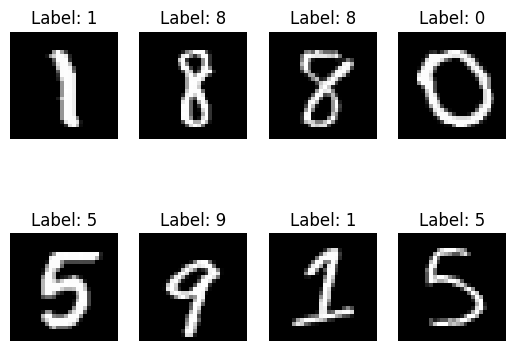

In [30]:
images, labels = next(iter(train_loader))
for i in range(8):
  plt.subplot(2,4, i+1)
  plt.imshow(images[i].squeeze(), cmap='gray')
  plt.title(f"Label: {labels[i].item()}")
  plt.axis("off")

plt.show()

In [31]:
class SimpleCNN(nn.Module):

    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels= 1, out_channels= 16,kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels= 16, out_channels= 16,kernel_size=3, padding=1) # FIX: in_channels should be 16

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        #fully connected layer
        # Output after two pooling layers (28 -> 14 -> 7) and 16 channels from conv2
        self.fc1 = nn.Linear(16 * 7 * 7, 128) # FIX: fc1 output should be 128 for fc2
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x) # FIX: Apply pooling

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        x = x.view(x.size(0), -1)

        x = self.fc1(x)
        x = self.relu(x) # Apply ReLU after fc1
        x = self.fc2(x) # Final layer, no ReLU here for CrossEntropyLoss

        return x

In [32]:
model = SimpleCNN().to(device)

print(model)

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [33]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [26]:
epochs = 50

train_losses_history = []
train_accuracy_history = []

for epoch in range(epochs):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    train_losses_history.append(epoch_loss)
    train_accuracy_history.append(epoch_accuracy)


    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

Epoch [1/50], Loss: 0.1753, Accuracy: 94.96%
Epoch [2/50], Loss: 0.0547, Accuracy: 98.27%
Epoch [3/50], Loss: 0.0392, Accuracy: 98.75%
Epoch [4/50], Loss: 0.0288, Accuracy: 99.05%
Epoch [5/50], Loss: 0.0239, Accuracy: 99.25%
Epoch [6/50], Loss: 0.0180, Accuracy: 99.40%
Epoch [7/50], Loss: 0.0144, Accuracy: 99.52%
Epoch [8/50], Loss: 0.0121, Accuracy: 99.59%
Epoch [9/50], Loss: 0.0111, Accuracy: 99.62%
Epoch [10/50], Loss: 0.0102, Accuracy: 99.67%
Epoch [11/50], Loss: 0.0080, Accuracy: 99.73%
Epoch [12/50], Loss: 0.0092, Accuracy: 99.69%
Epoch [13/50], Loss: 0.0059, Accuracy: 99.79%
Epoch [14/50], Loss: 0.0056, Accuracy: 99.80%
Epoch [15/50], Loss: 0.0080, Accuracy: 99.75%
Epoch [16/50], Loss: 0.0054, Accuracy: 99.81%
Epoch [17/50], Loss: 0.0031, Accuracy: 99.89%
Epoch [18/50], Loss: 0.0068, Accuracy: 99.79%
Epoch [19/50], Loss: 0.0058, Accuracy: 99.80%
Epoch [20/50], Loss: 0.0030, Accuracy: 99.90%
Epoch [21/50], Loss: 0.0054, Accuracy: 99.82%
Epoch [22/50], Loss: 0.0057, Accuracy: 99.7

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.subplot(1,2,1)
plt.plot(train_losses_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(train_accuracy_history)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

In [ ]:
#Image Processing Using Open CV

#Upload image using button open collab

import matplotlib.pyplot as plt
import numpy as np
import cv2
from google.colab import files
import os

print("Please Select An Image")

uploaded = files.upload()


#Get uploaded file name

image_path = list(uploaded.keys())[0]

print(f"\nUploaded Image: {image_path}")


#load Image

image = cv2.imread(image_path) #this is us reading the image using opencv

if image is None:
  raise FileNotFoundError("Image Could Not Be Loaded")

#Convert BGR to RGB

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) #Converting the image to RGB since Open CV only takes images in BGR


#RESIZE IMAGE

resized = cv2.resize(image_rgb, (300,300))

#GRAYSCALE

gray = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)


#GAUSSIAN_BLUR

blur = cv2.GaussianBlur(gray, (5,5), 0)

#Histogram EQUALIZATION

equalized = cv2.equalizeHist(blur)


#Thresholding //This is us setting up threshold image

_, threshold_img = cv2.threshold(
    equalized,
    127,
    255,
    cv2.THRESH_BINARY
)



#EDGE DETECTION
edges = cv2.Canny(
    equalized,
    100,
    200
)


#DISPLAY ALL RESULTS

titles = [
    "Original",
    "Grayscale",
    "Gaussian Blur",
    "Histogram Equalization",
    "Threshold",
    "Edge Detection"
]


images = [
    resized,
    gray,
    blur,
    equalized,
    threshold_img,
    edges
]


plt.figure(figsize=(15,8))

for i in range(len(images)):
  plt.subplot(2,3,i+1)

  if len(images[i].shape) == 2:
    plt.imshow(images[i], cmap="gray")
  else:
    plt.imshow(images[i])

    plt.title(titles[i], fontsize=11)
  plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#YOLO#
!pip install ultralytics


import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import files


#upload image

print("="*60)
print("UPLOAD AN IMAGE")
print("="*60)

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

print(f"\nUploaded Image: {image_path}")


#Load pretrained YOLOv8 Models
print("\nLoading YOLOv8 Model...")
model = YOLO("yolov5x.pt")
print("Model Loaded Successfully")




#Object Detecttion
print("\nPerforming object Detetction")
results = model(image_path)
print("Detection Completed Successfully")


#Display Detected Image

result = results[0]
annotated_image = result.plot()

annotate_image = cv2.cvtColor(
    annotated_image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10,10))
plt.imshow(annotated_image)
plt.title("YLLOv8 Object Detection Result")
plt.axis("off")
plt.show()


#Print Detected Objects

print("\n" + "="*60)
print("Detected Objects")
print("="*60)

if len(result.boxes) == 0:
  print("No Objects detected")
else:

  for i, box in enumerate(result.boxes):

    cls = int(box.cls)
    confidence = float(box.conf)

    object_name = model.names[cls]

    print(f"\nObject {i+1}")
    print("-"*30)
    print(f"Class Name: {object_name}")
    print(f"Confidence: {confidence}")


    #Total Objects

    print("\n" + "="*60)
    print(f"Total Objects Detected : {len(result.boxes)}")
    print("="*60)

In [ ]:
#YOLO#
!pip install ultralytics


import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import files


#upload image

print("="*60)
print("UPLOAD AN IMAGE")
print("="*60)

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

print(f"\nUploaded Image: {image_path}")


#Load pretrained YOLOv8 Models
print("\nLoading YOLOv8 Model...")
model = YOLO("yolov8x.pt")
print("Model Loaded Successfully")




#Object Detecttion
print("\nPerforming object Detetction")
results = model(image_path)
print("Detection Completed Successfully")


#Display Detected Image

result = results[0]
annotated_image = result.plot()

annotate_image = cv2.cvtColor(
    annotated_image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10,10))
plt.imshow(annotated_image)
plt.title("YLLOv8 Object Detection Result")
plt.axis("off")
plt.show()


#Print Detected Objects

print("\n" + "="*60)
print("Detected Objects")
print("="*60)

if len(result.boxes) == 0:
  print("No Objects detected")
else:

  for i, box in enumerate(result.boxes):

    cls = int(box.cls)
    confidence = float(box.conf)

    object_name = model.names[cls]

    print(f"\nObject {i+1}")
    print("-"*30)
    print(f"Class Name: {object_name}")
    print(f"Confidence: {confidence}")


    #Total Objects

    print("\n" + "="*60)
    print(f"Total Objects Detected : {len(result.boxes)}")
    print("="*60)

In [34]:
#SSD OBJECT DETECTION USING PYTORCH

#AIM: A traffic monitoring system needs vechicle detection\



In [35]:
# Install required libraries

!pip -q install torch torchvision

import torch
import torchvision
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from google.colab import files



In [36]:
#UPLOAD IMAGE

print("="*60)
print("UPLOAD TRAFFIC IMAGE")
print("="*60)

uploaded = files.upload()
image_path = list(uploaded.keys())[0]




UPLOAD TRAFFIC IMAGE


Saving Traffic.jpg to Traffic (1).jpg


In [37]:
#LOAD SSD MODEL

print("\nLoading SSD300 Model..")

weights = torchvision.models.detection.SSD300_VGG16_Weights.DEFAULT

model = torchvision.models.detection.ssd300_vgg16(
    weights = weights
)

model.eval()

print("Model Loaded Successfully")





Loading SSD300 Model..
Model Loaded Successfully


In [38]:
#LOAD IMAGE


image = Image.open(image_path).convert("RGB")

transform = weights.transforms()

input_tensor = transform(image).unsqueeze(0)


In [39]:
#OBJECT DETECTTION

with torch.no_grad():

  prediction = model(input_tensor)[0]




In [40]:
#COCO CLASS NAMES

COCO_CLASSES = [
'__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane',
'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant',
'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse',
'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack',
'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
'snowboard', 'sports ball', 'kite', 'baseball bat',
'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot',
'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop',
'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven',
'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase',
'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

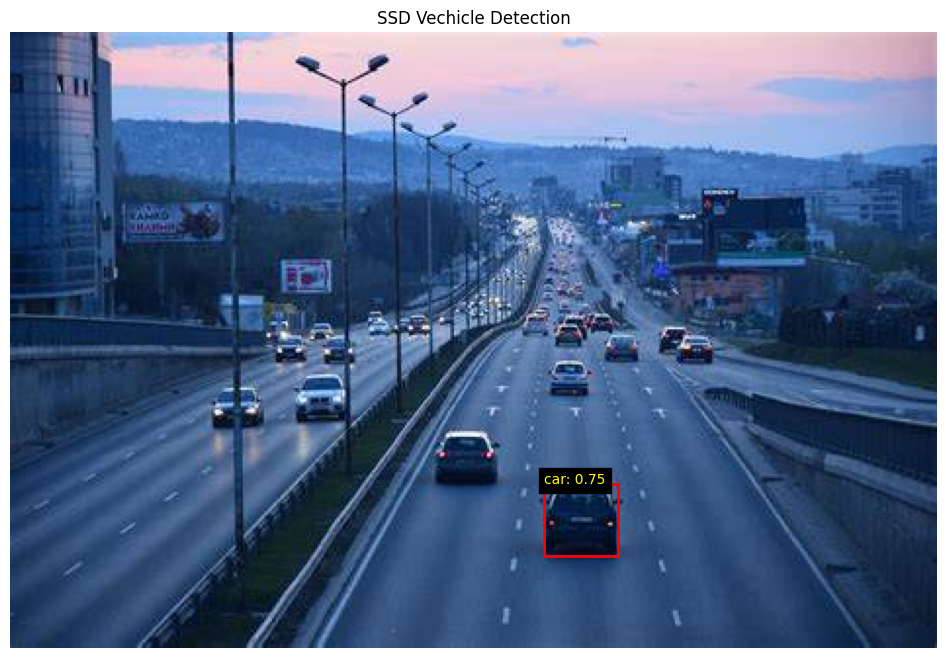

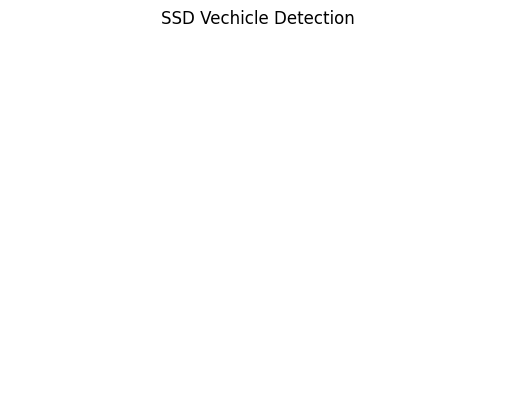

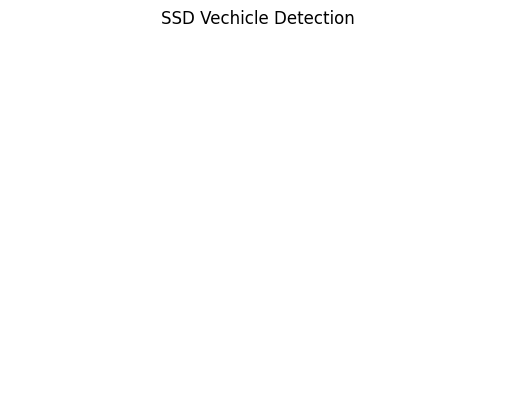

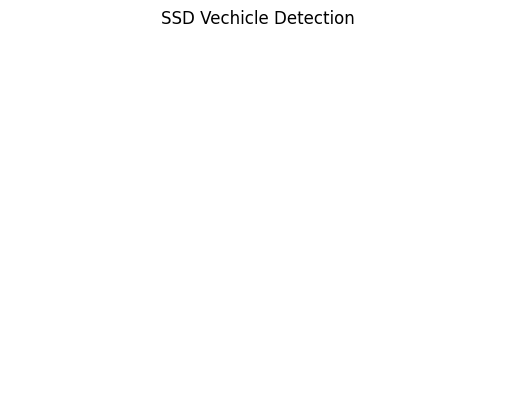

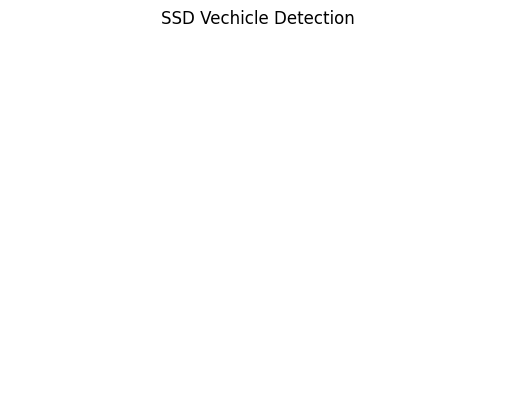

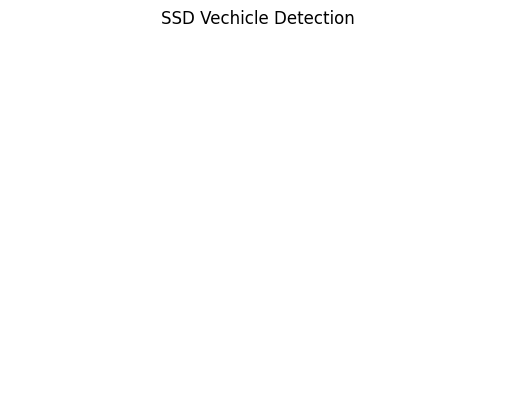

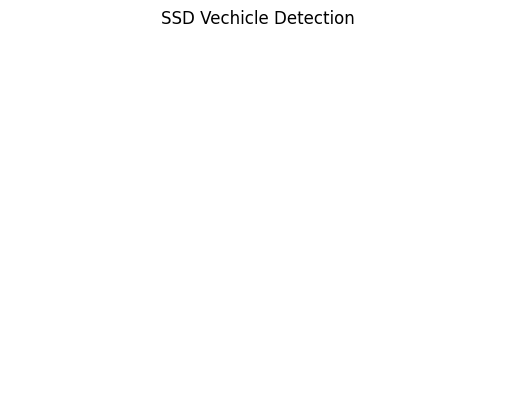

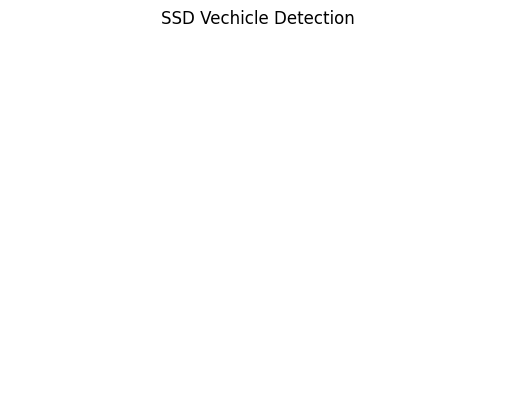

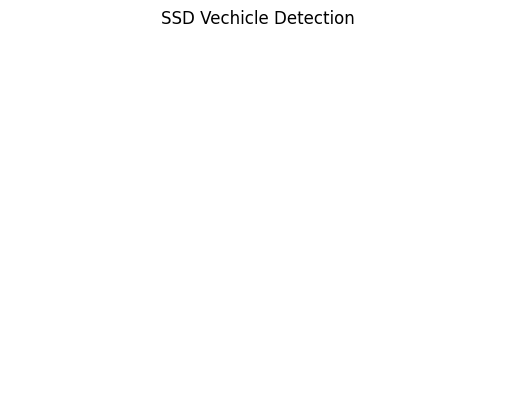

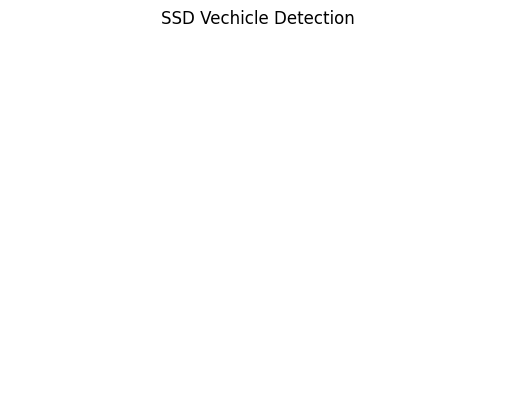

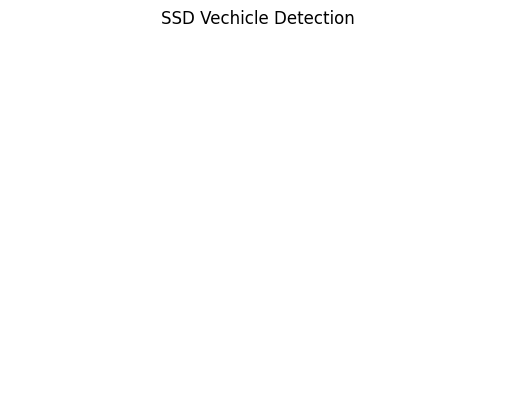

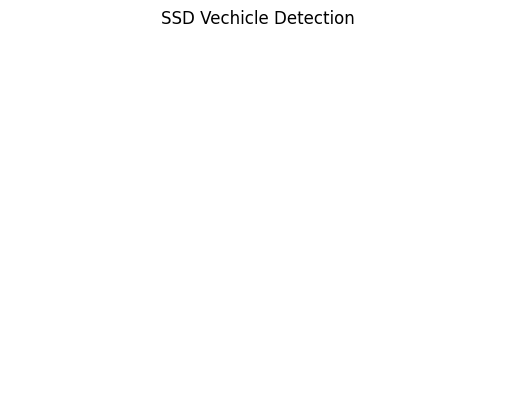

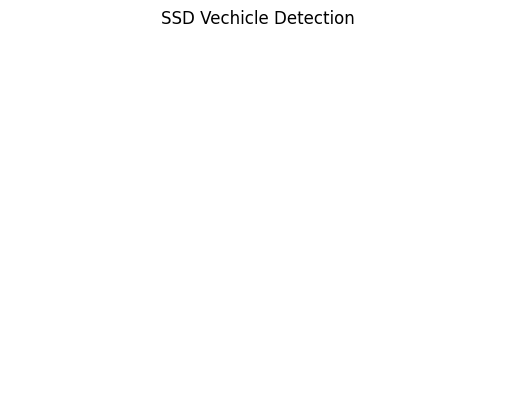

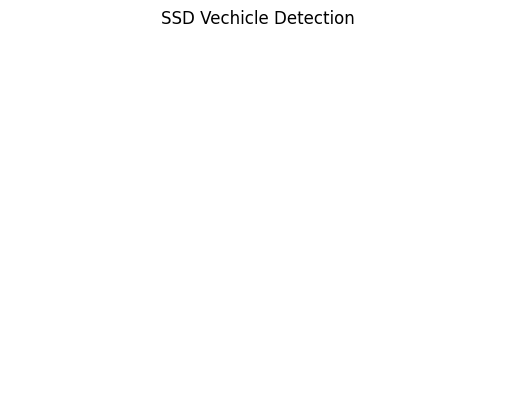

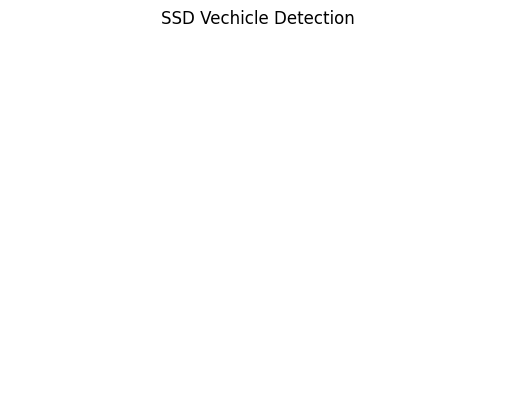

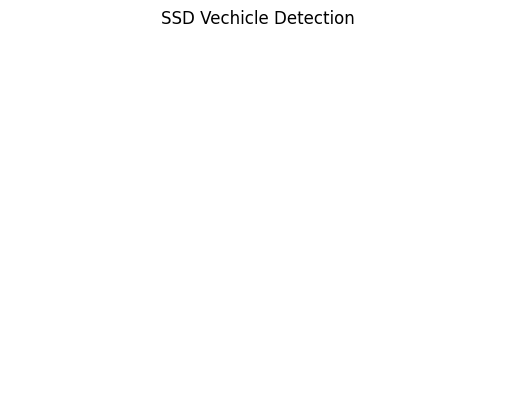

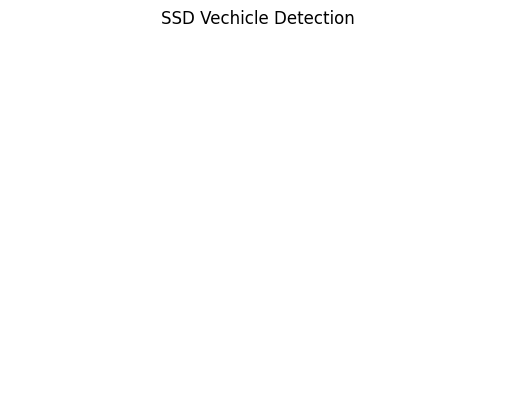

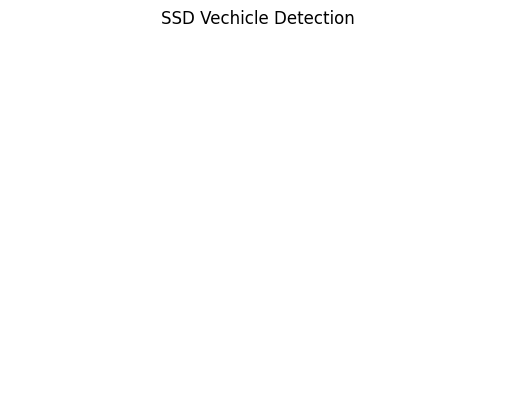

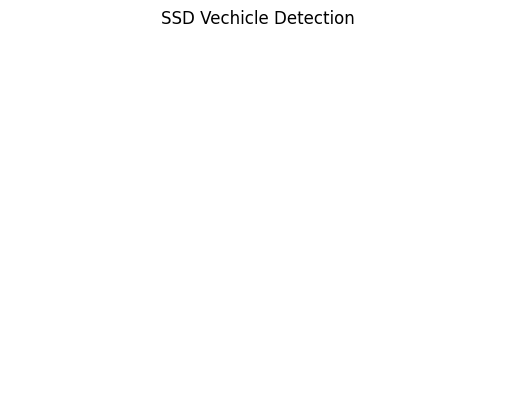

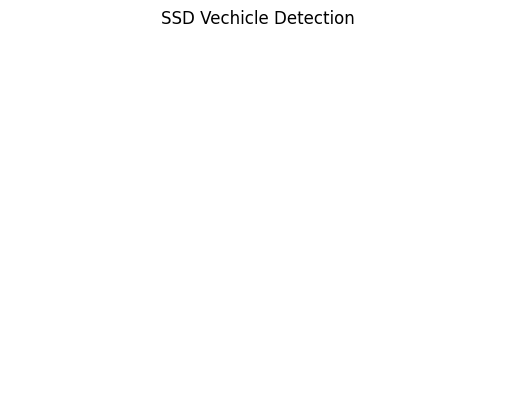

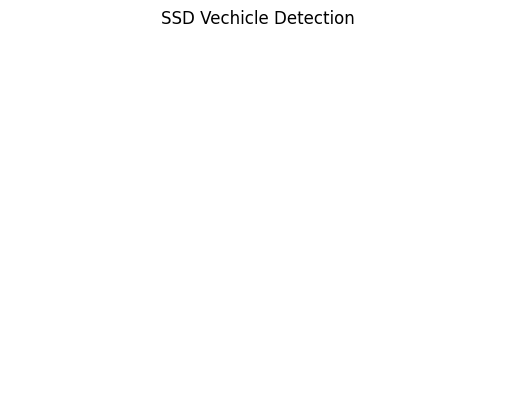

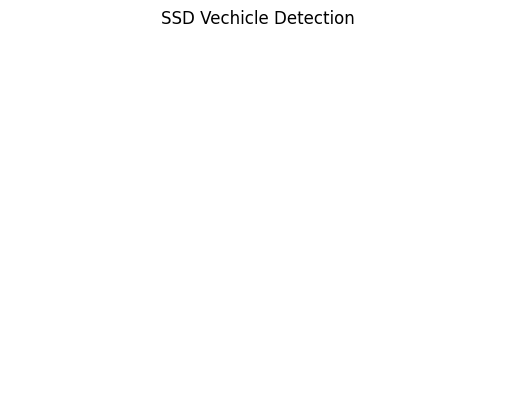

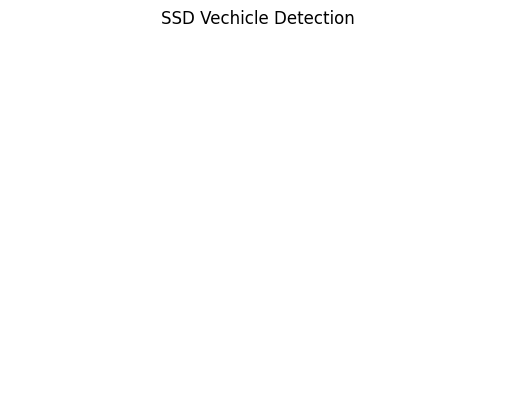

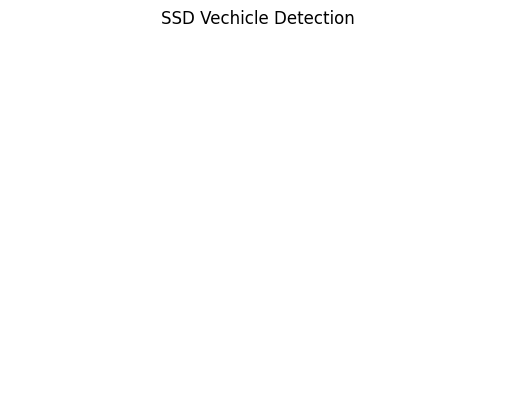

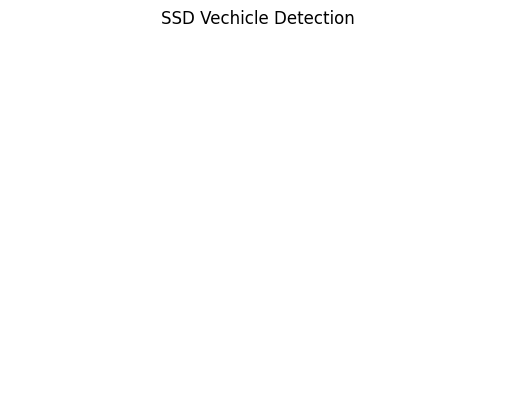

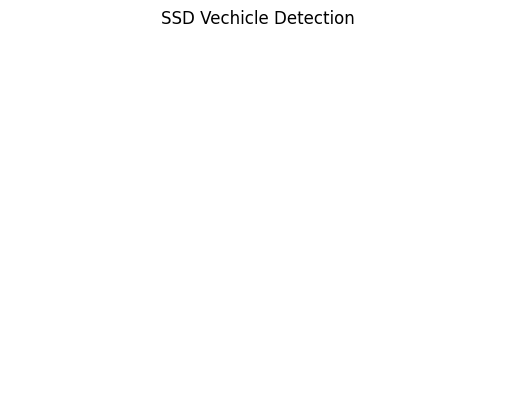

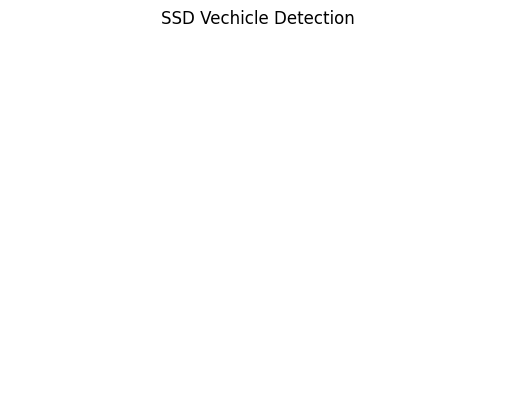

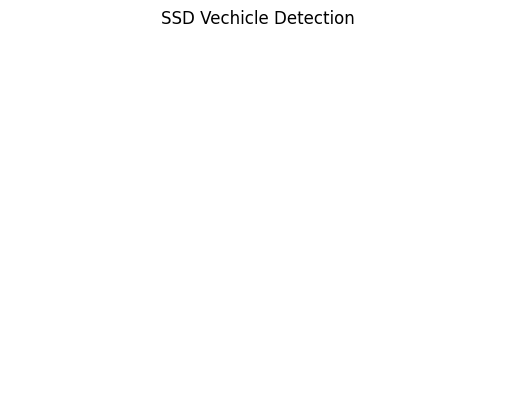

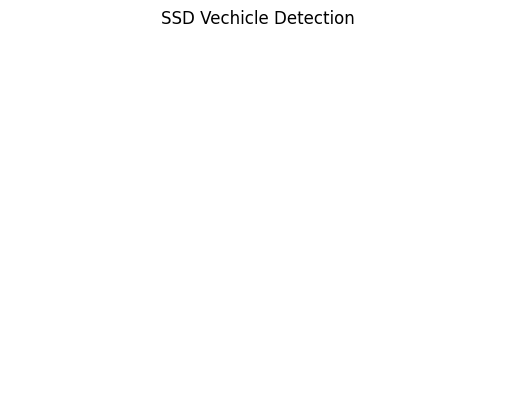

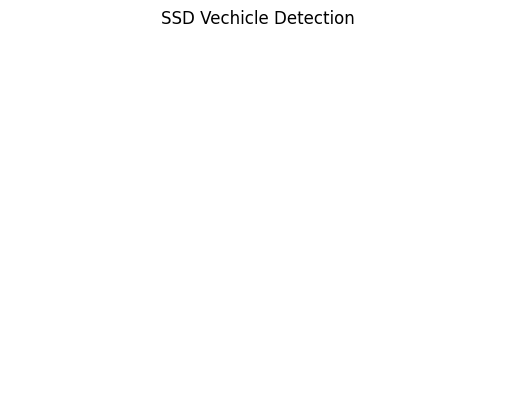

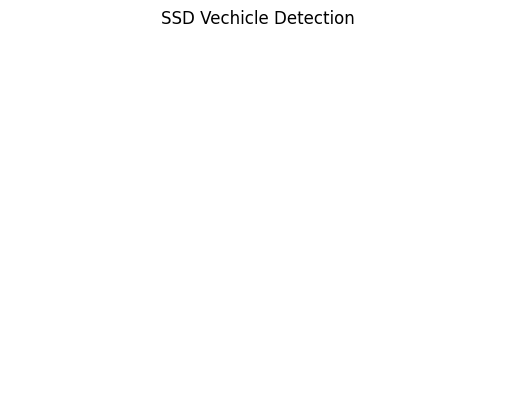

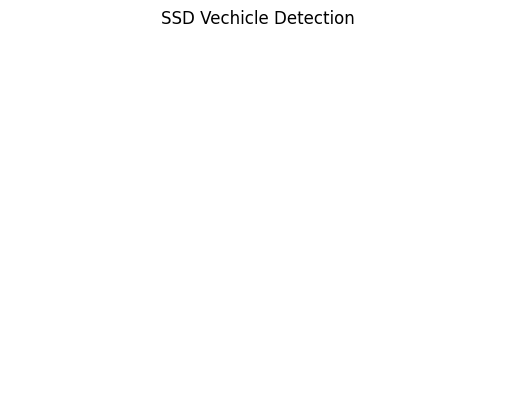

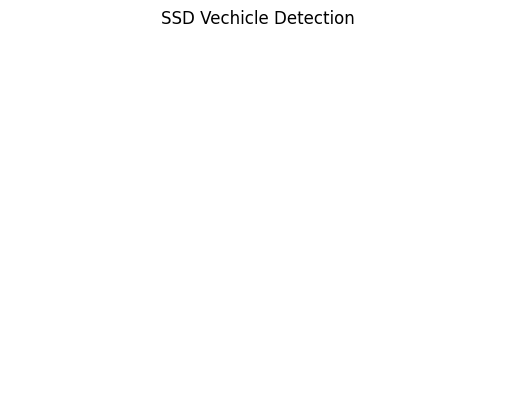

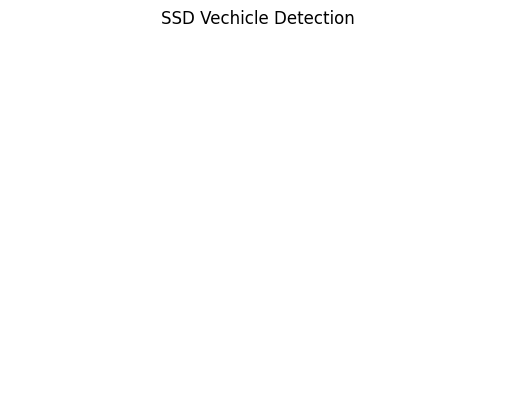

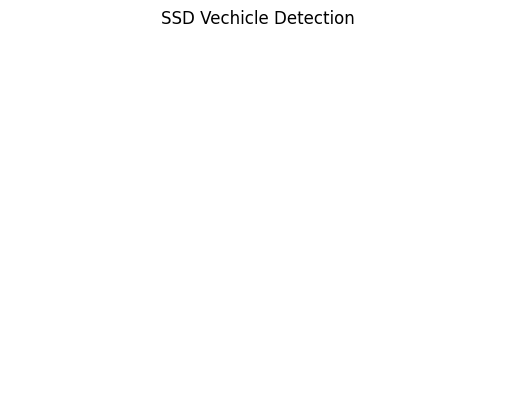

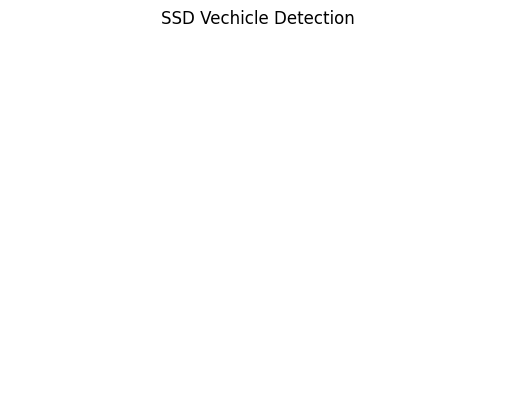

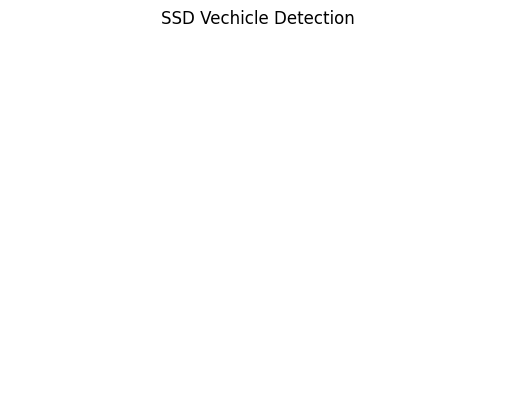

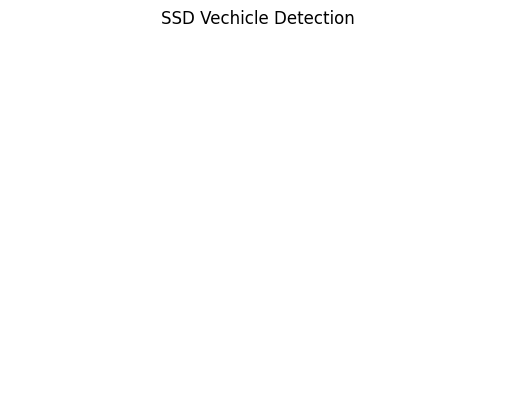

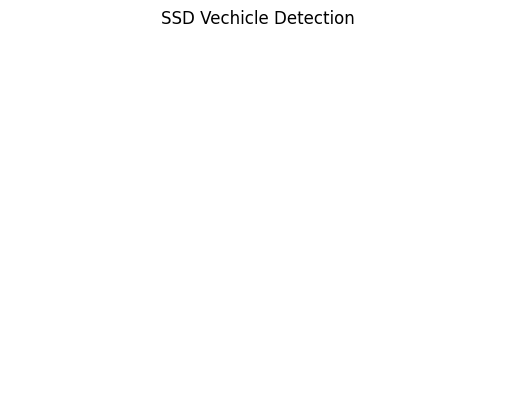

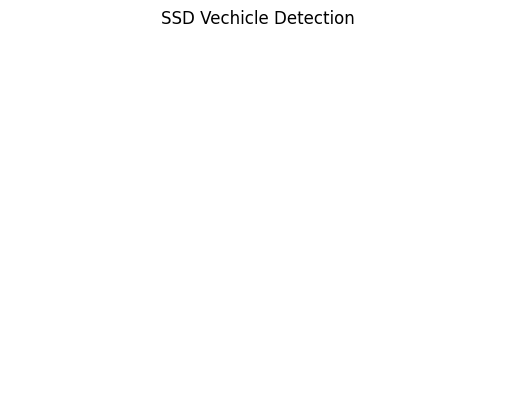

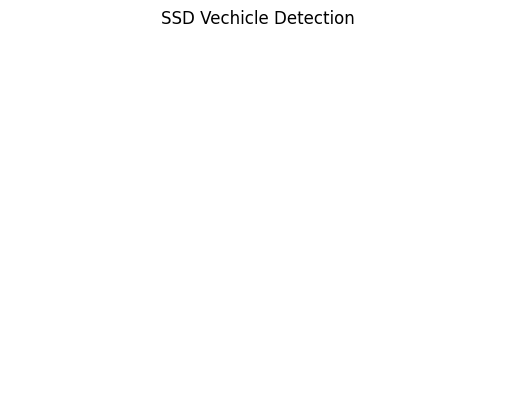

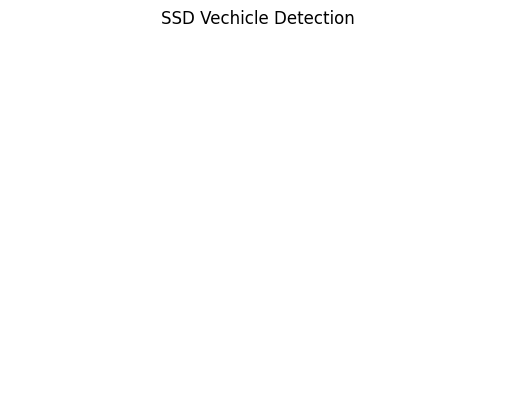

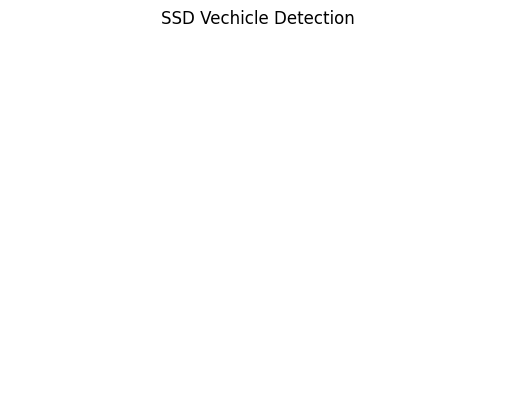

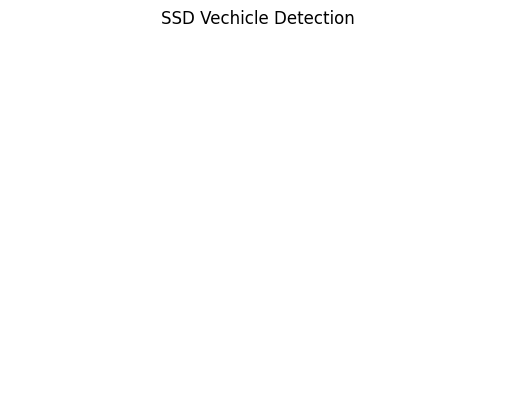

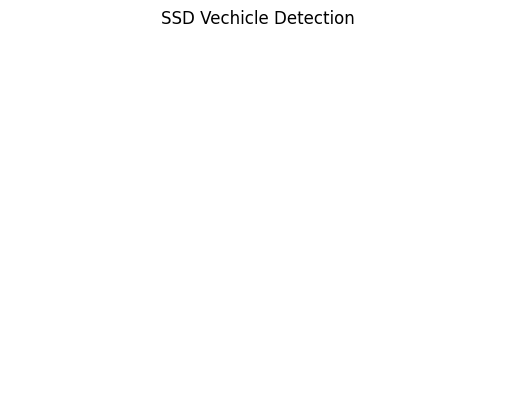

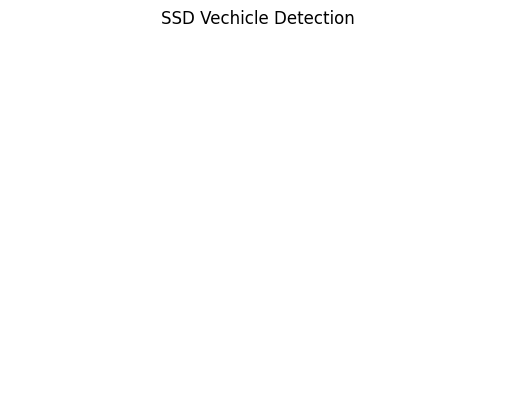

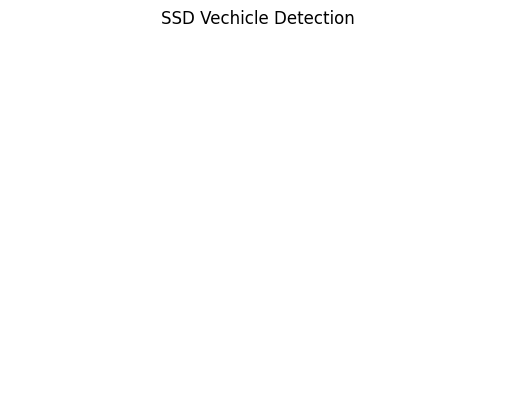

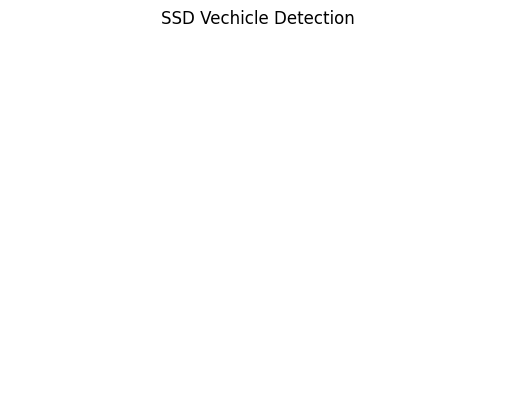

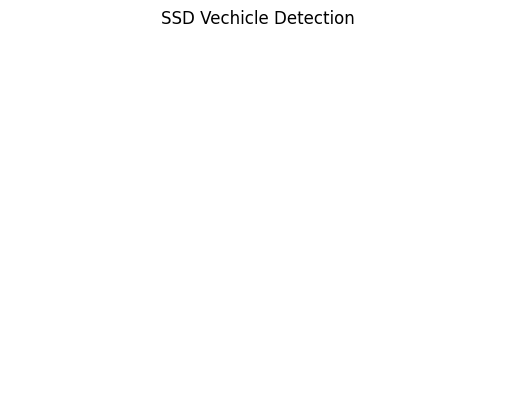

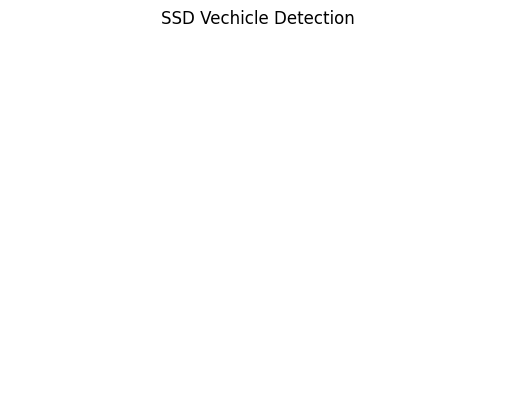

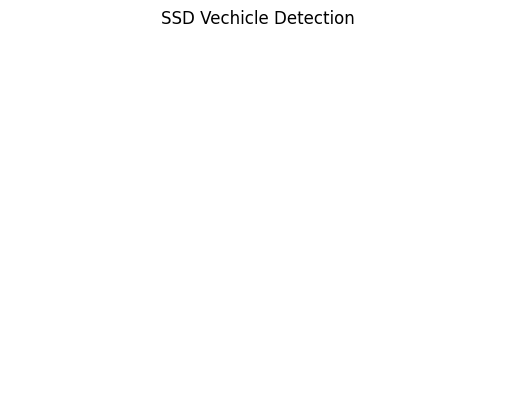

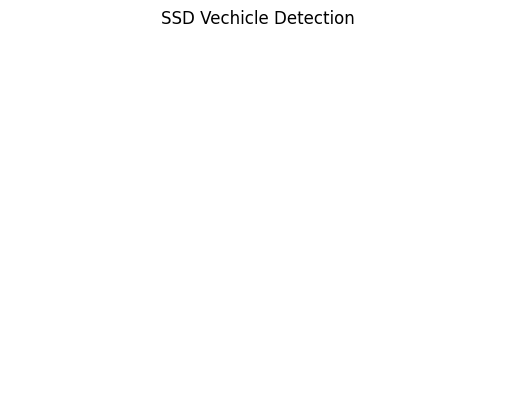

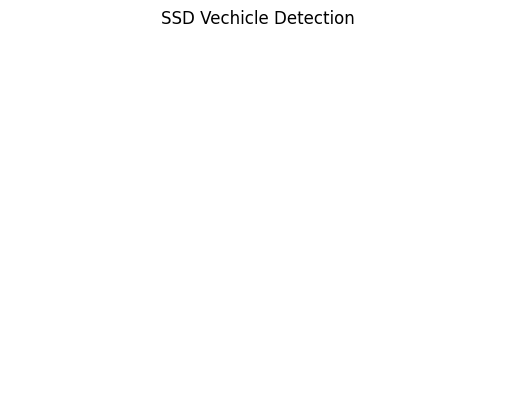

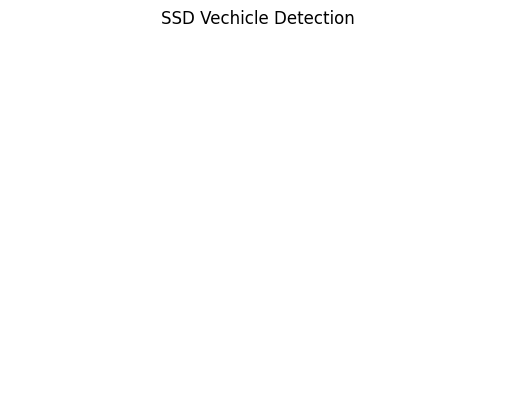

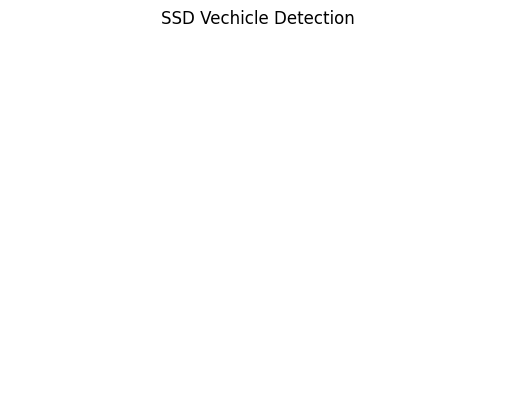

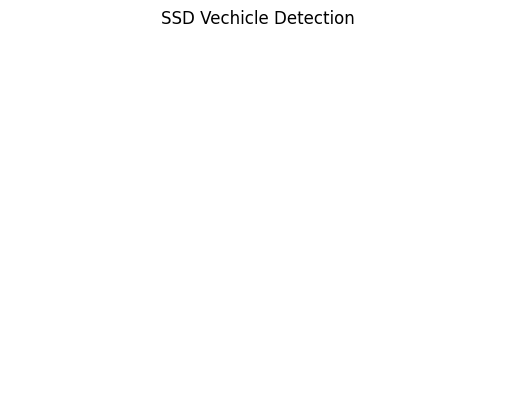

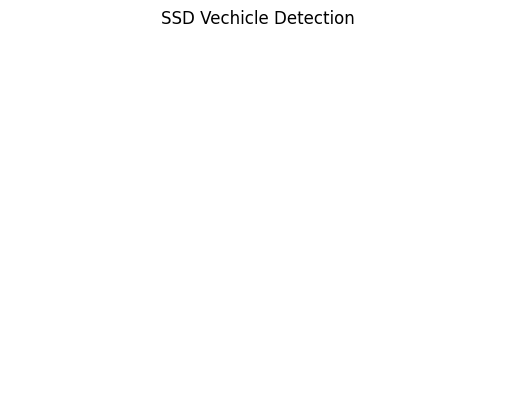

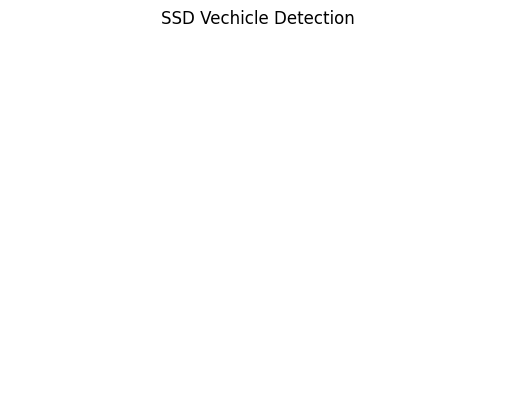

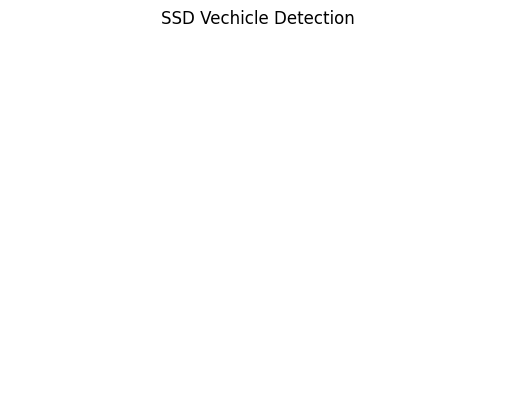

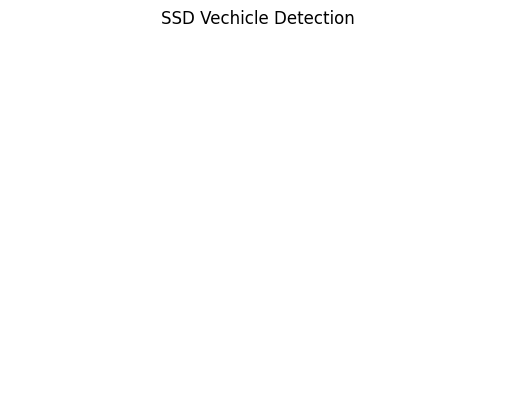

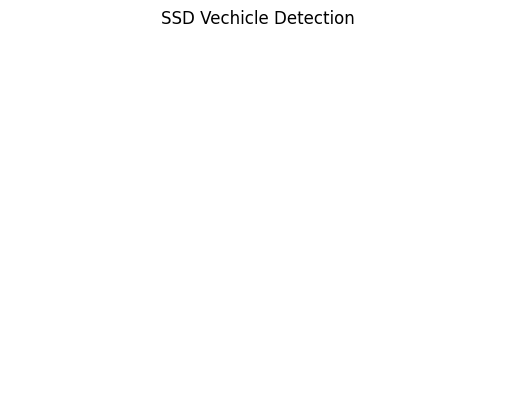

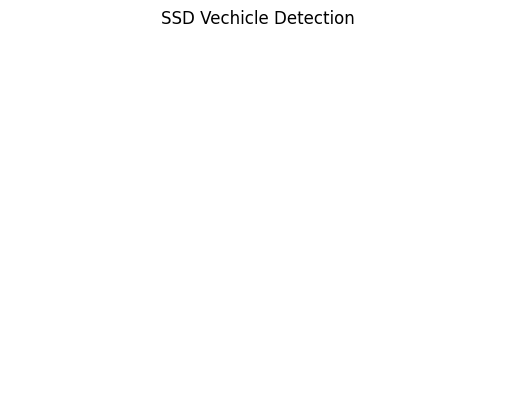

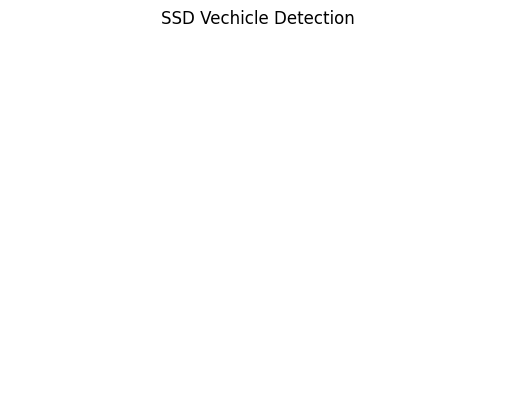

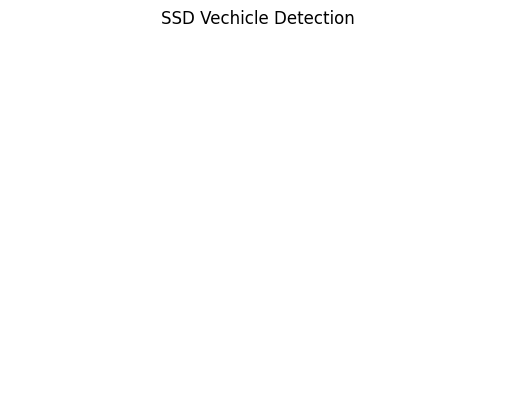

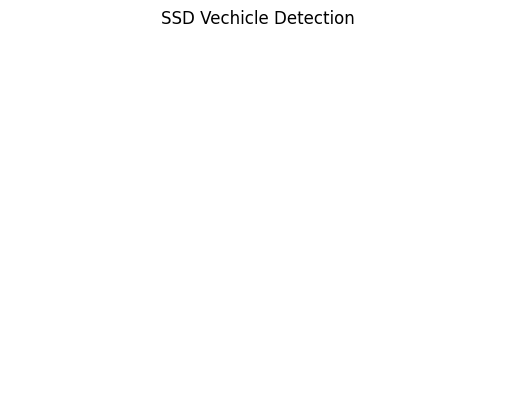

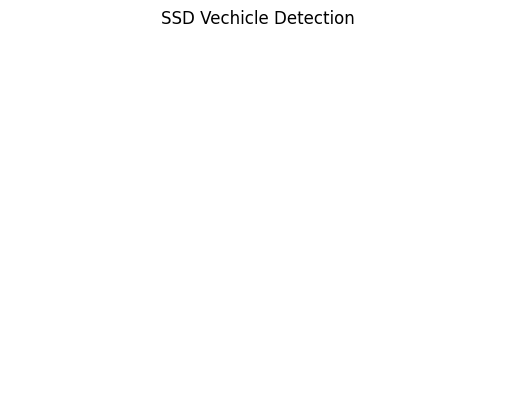

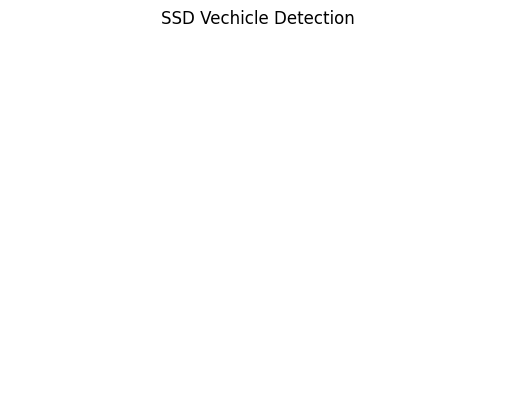

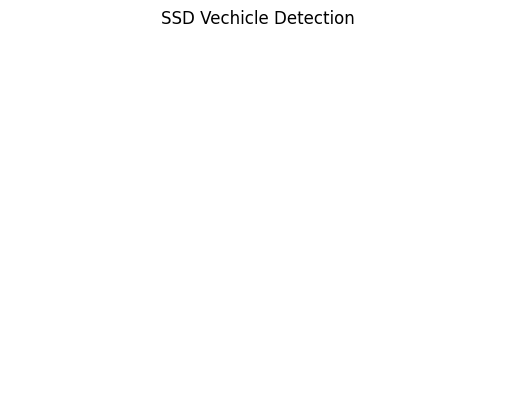

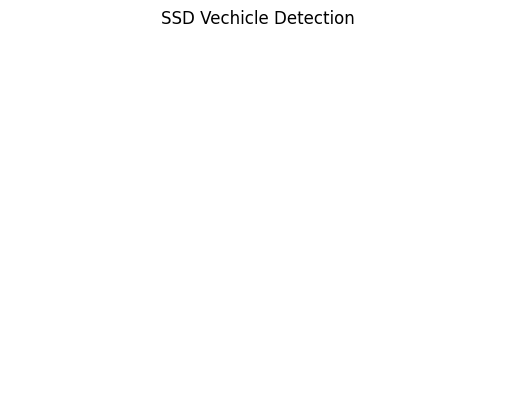

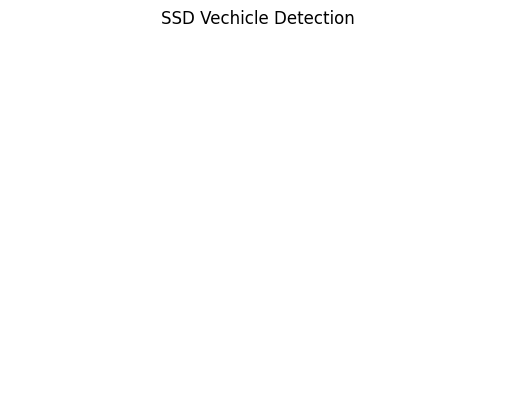

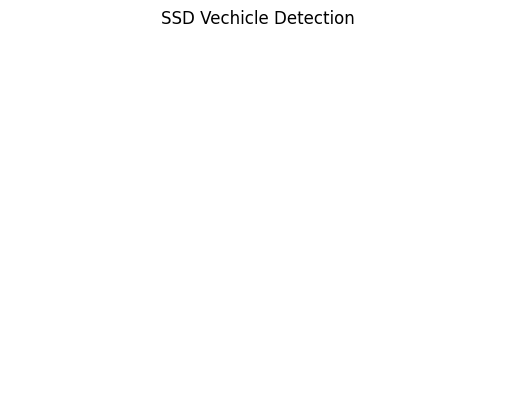

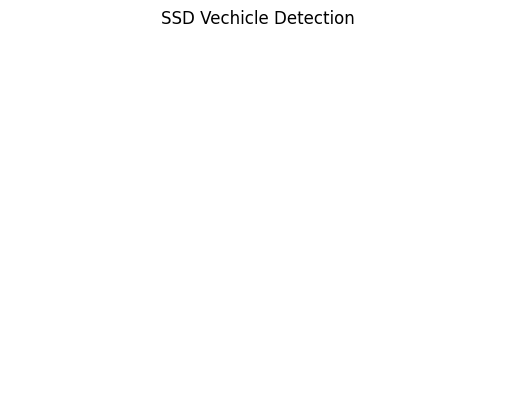

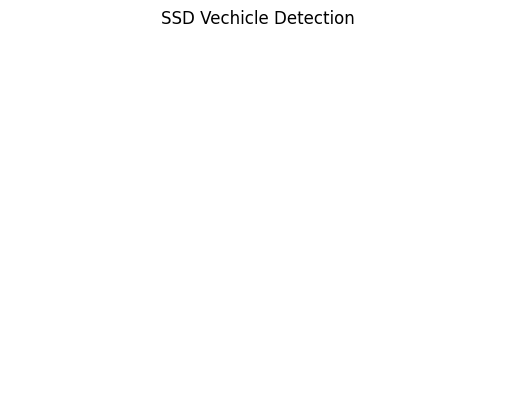

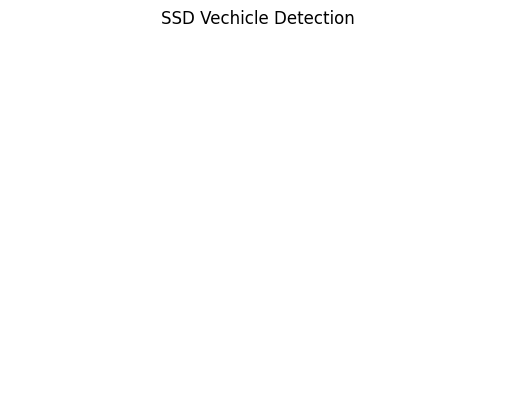

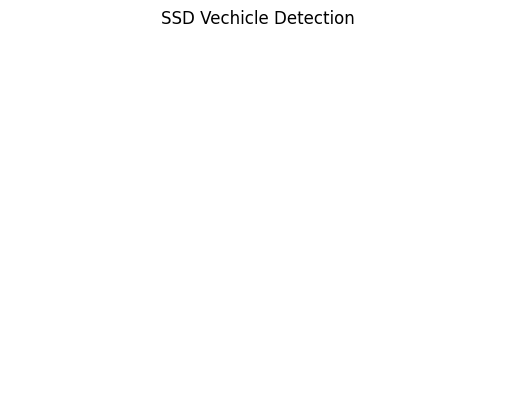

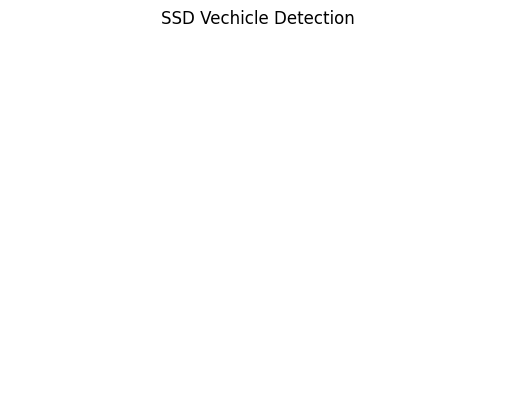

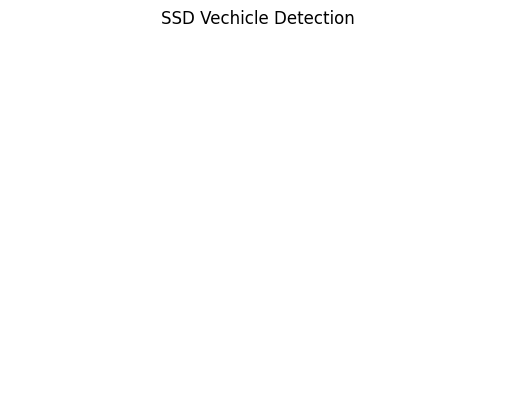

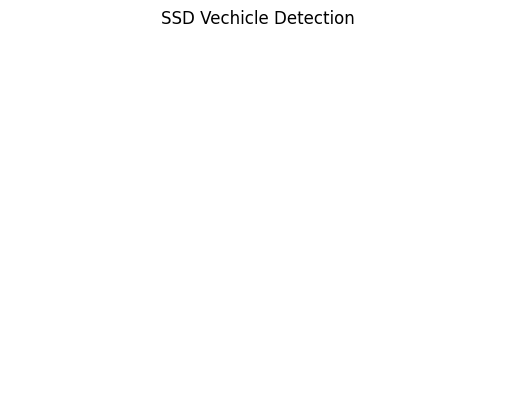

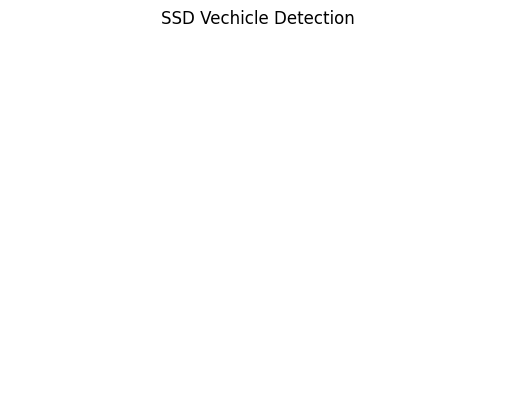

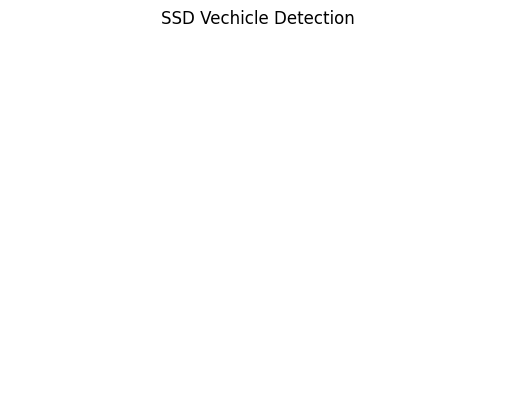

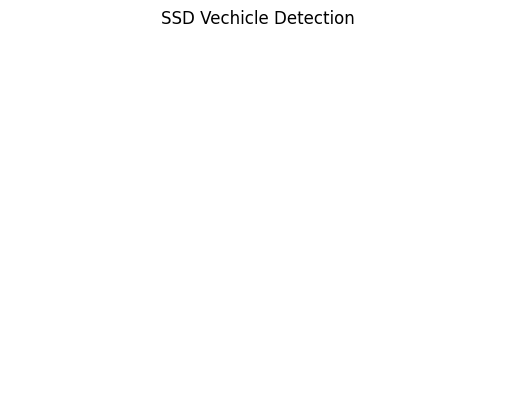

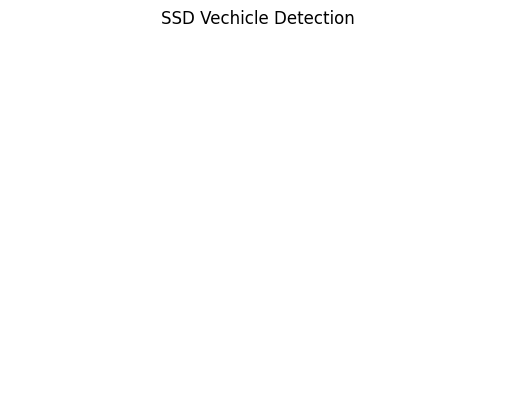

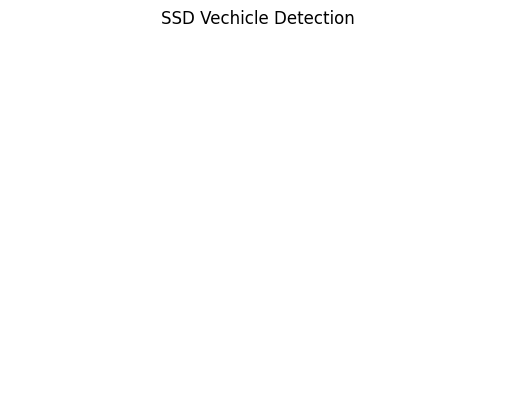

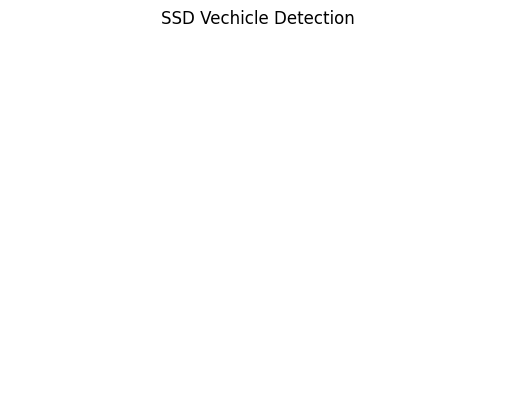

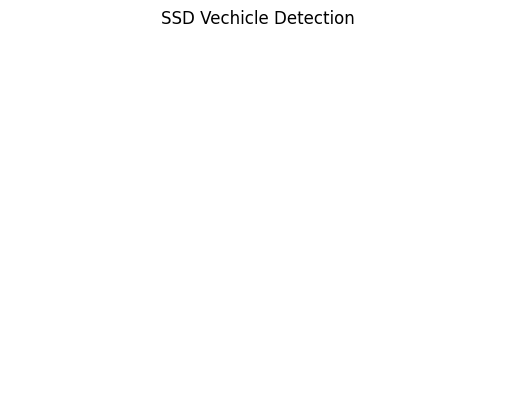

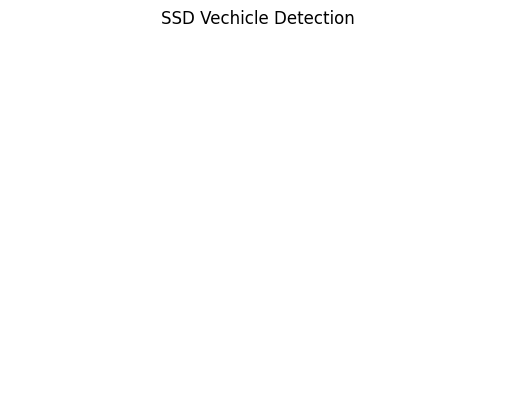

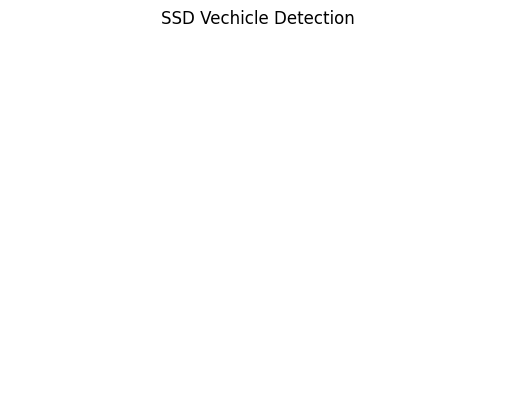

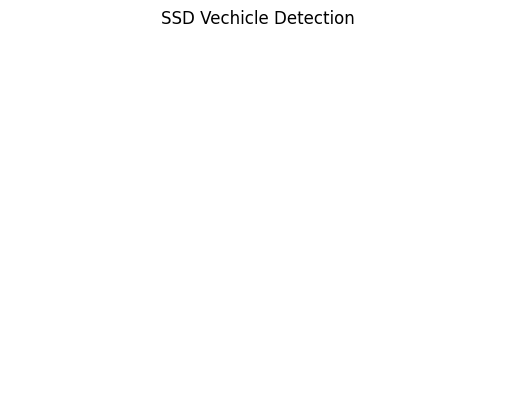

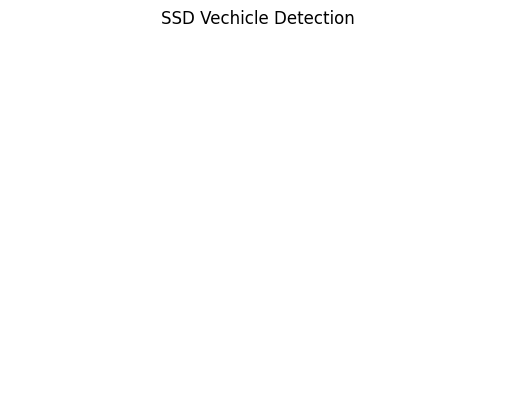

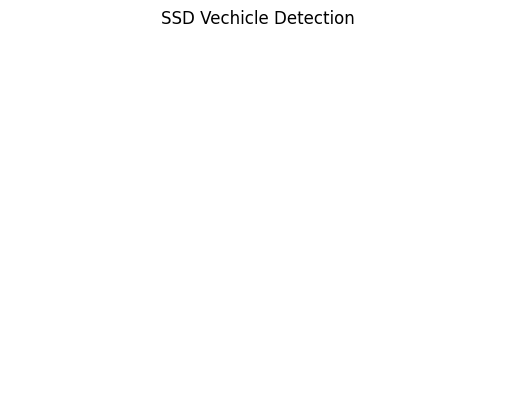

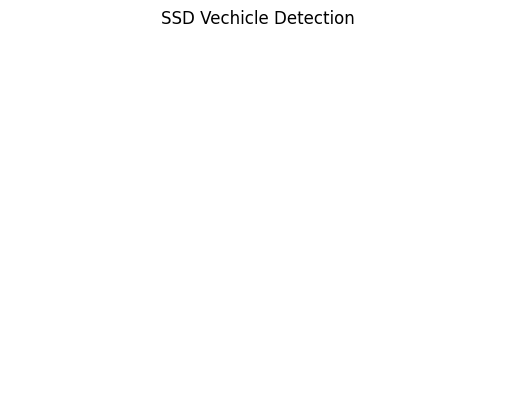

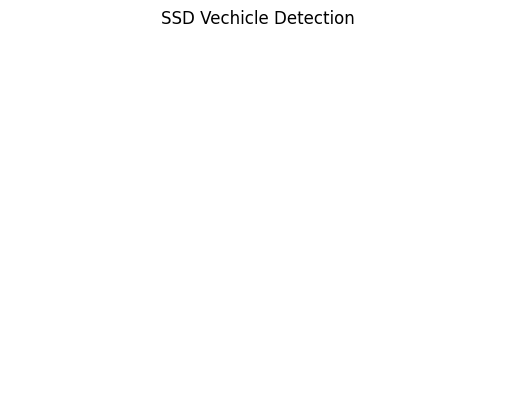

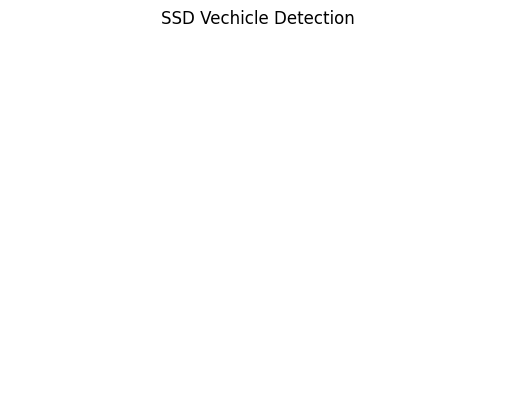

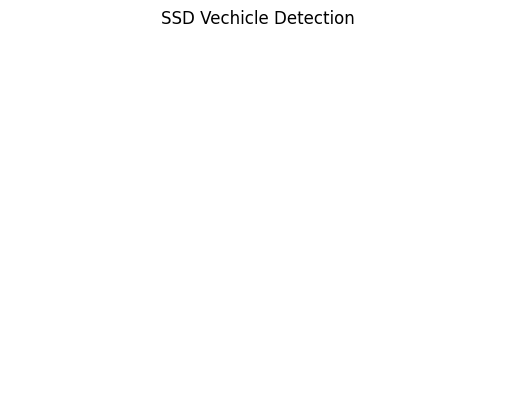

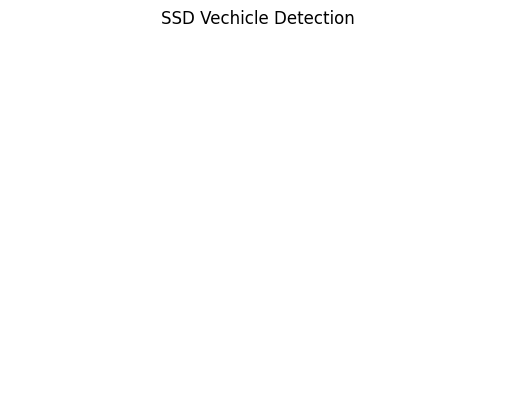

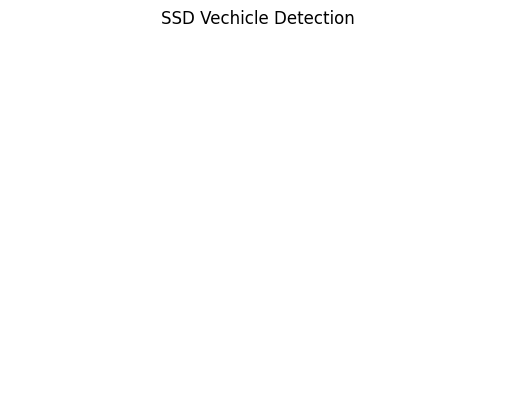

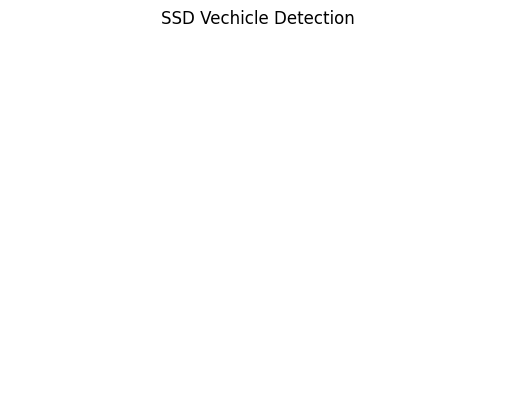

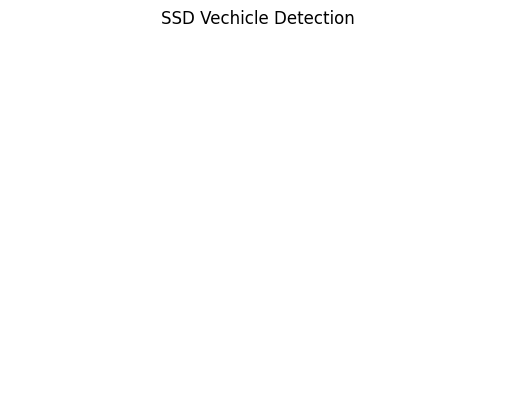

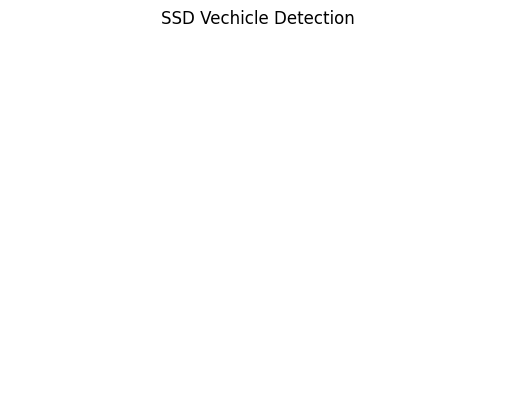

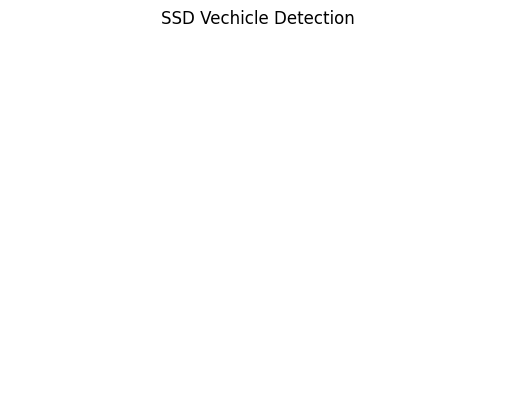

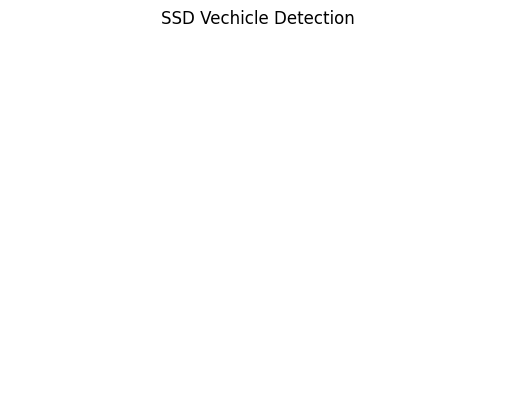

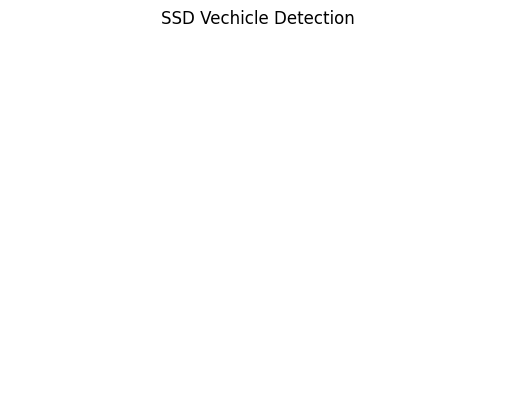

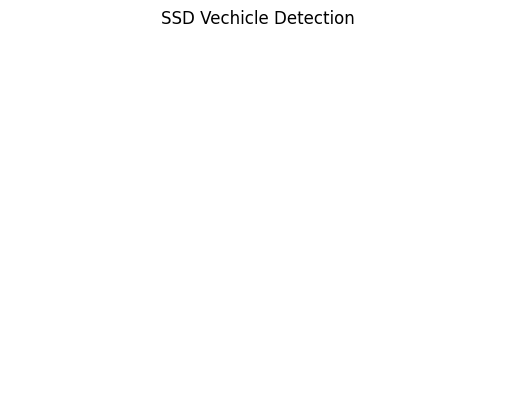

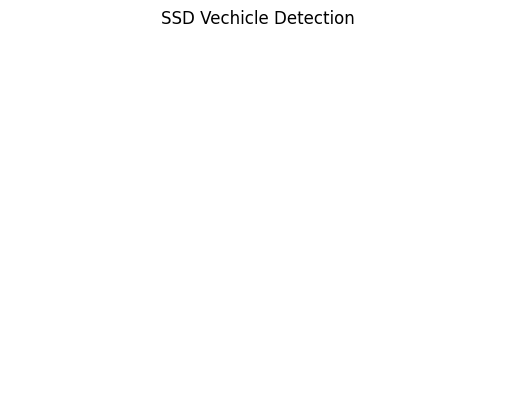

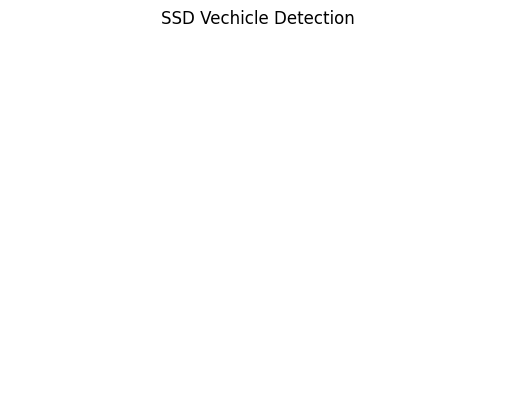

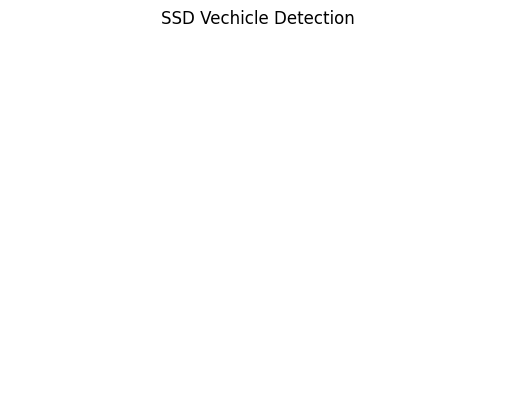

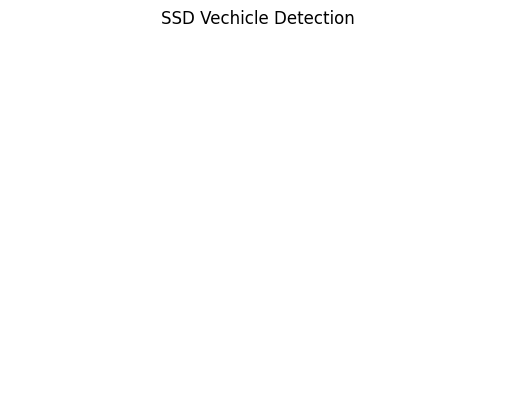

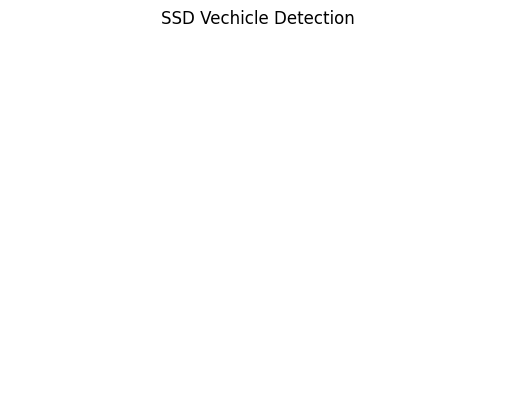

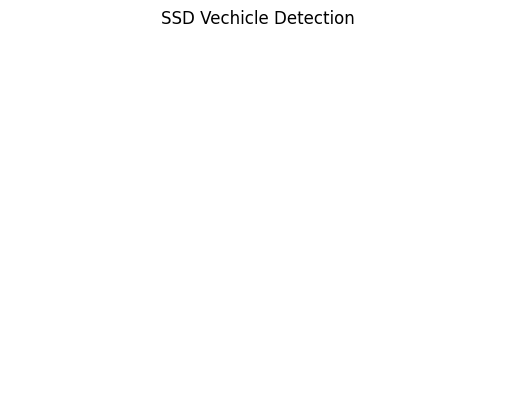

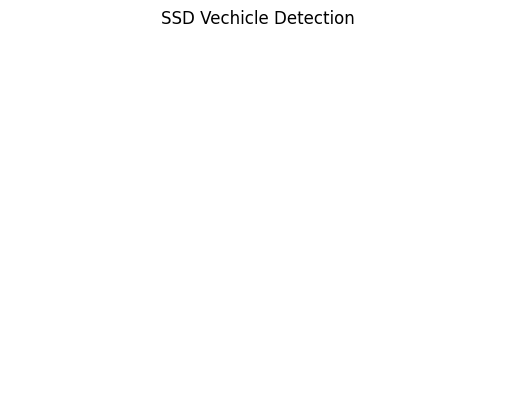

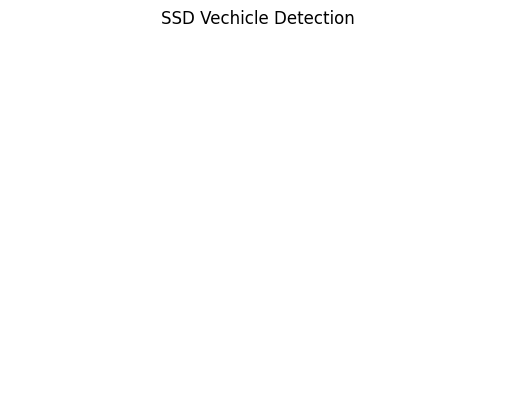

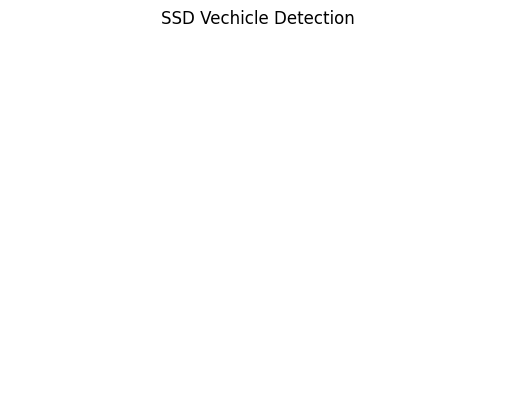

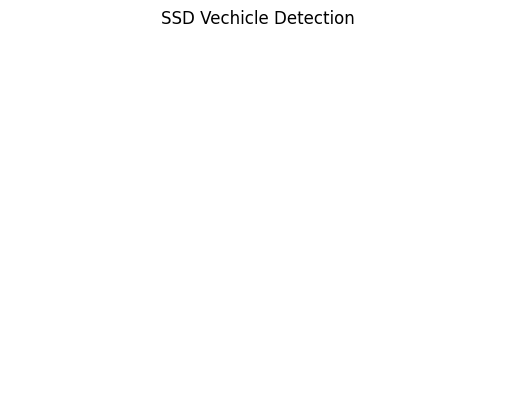

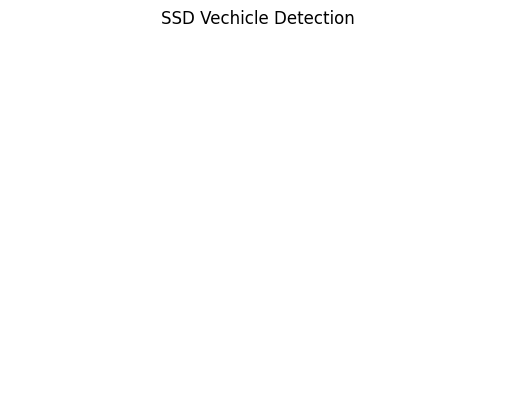

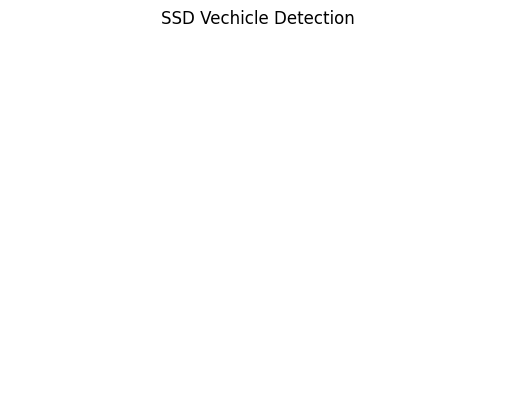

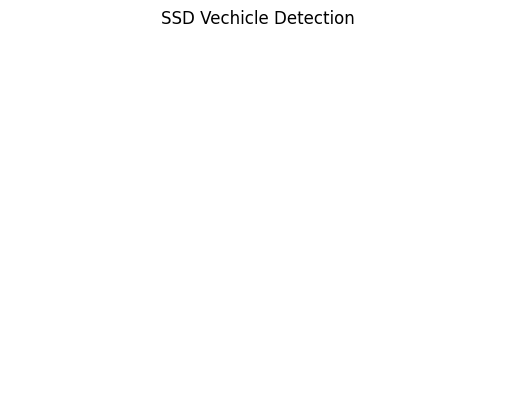

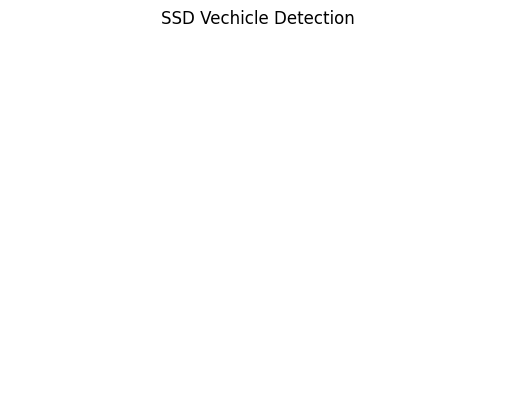

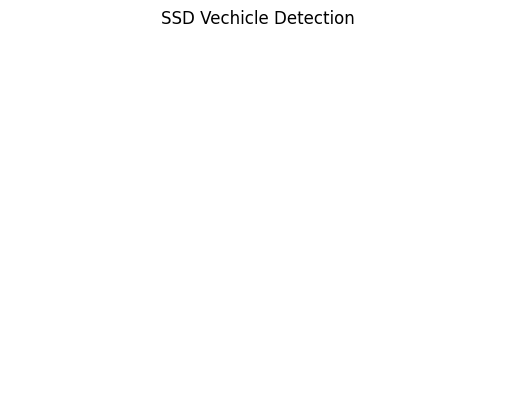

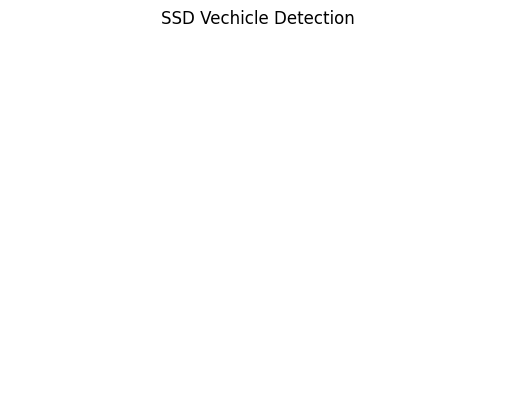

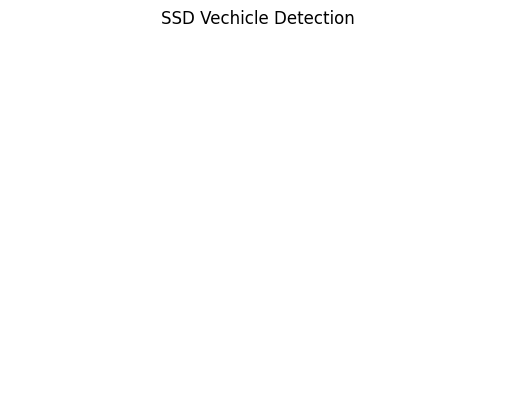

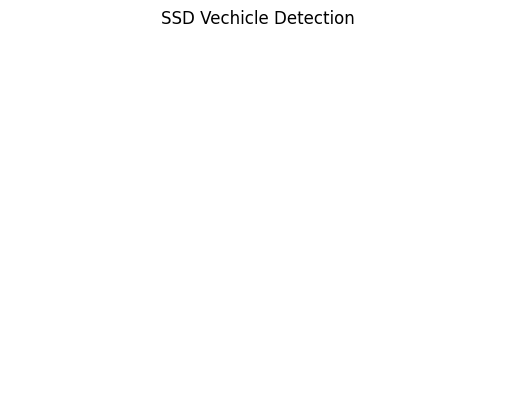

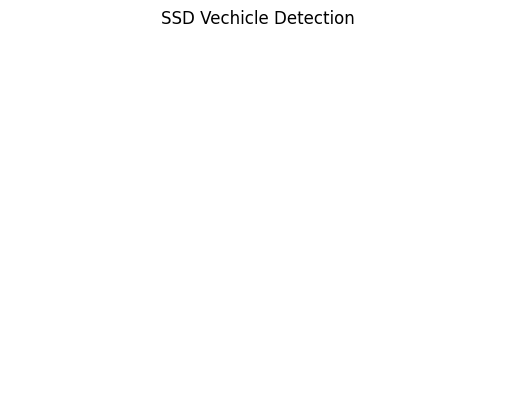

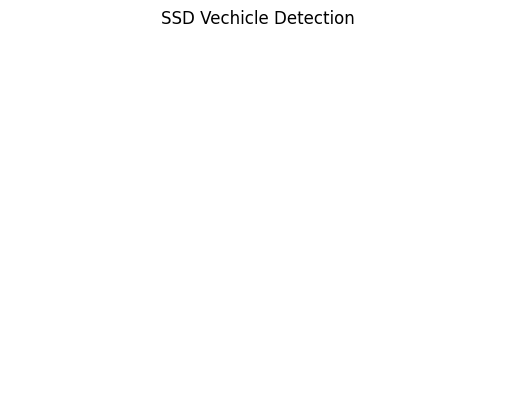

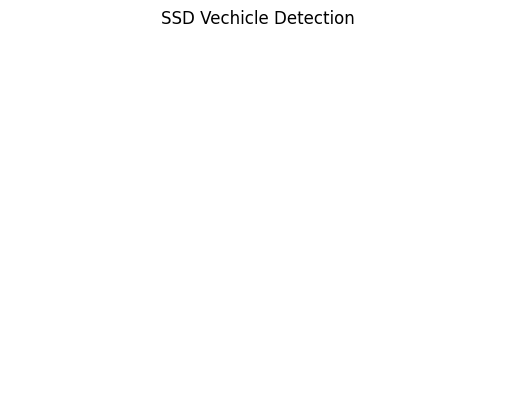

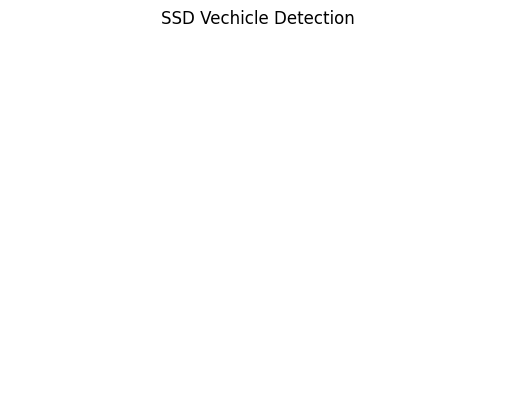

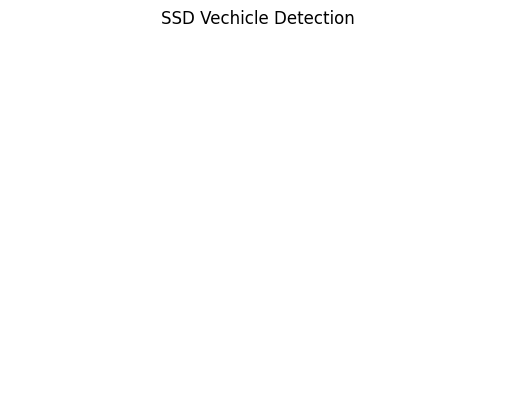

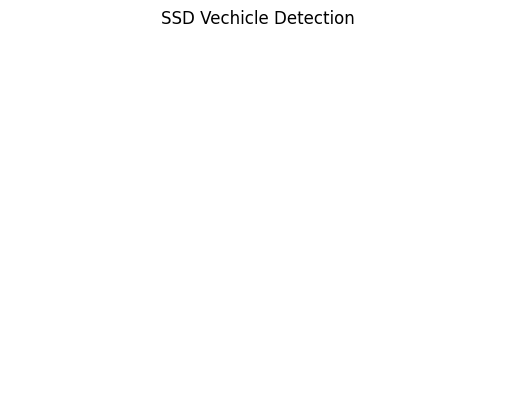

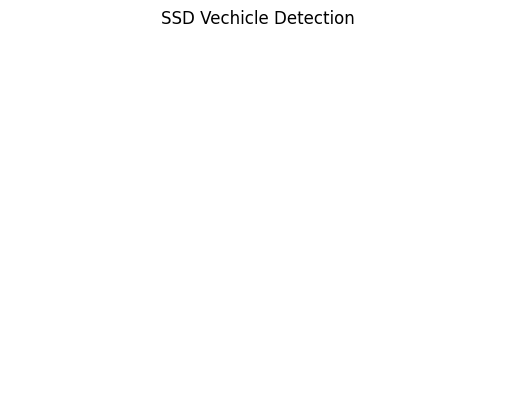

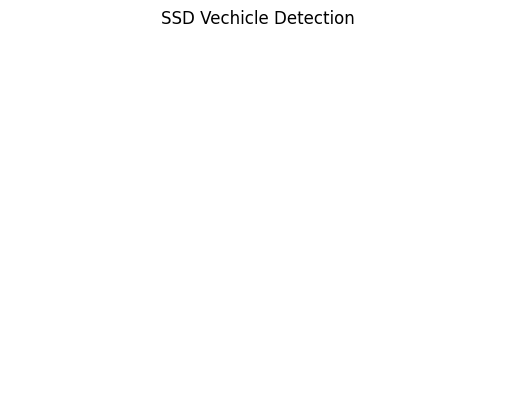

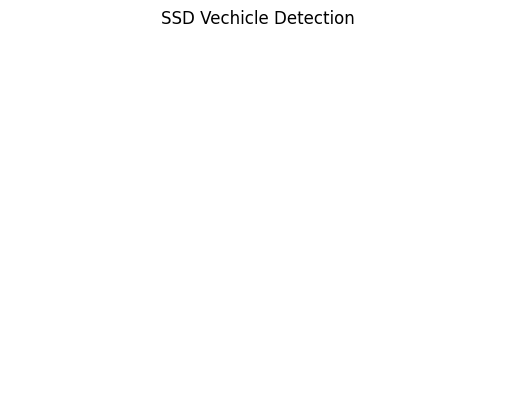

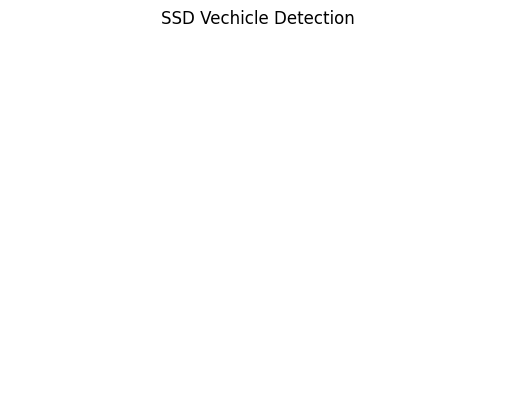

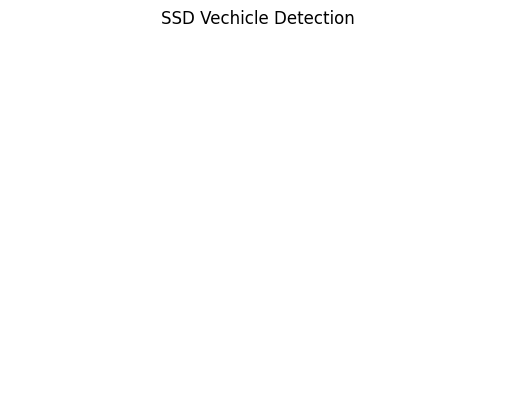

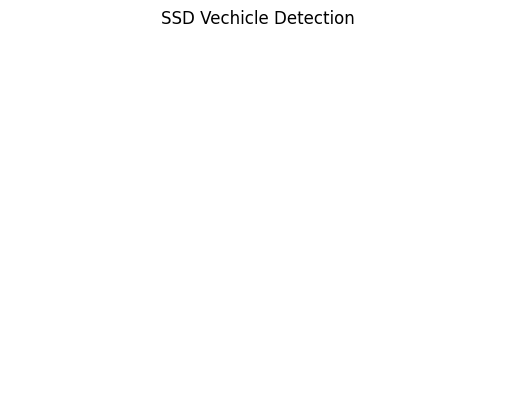

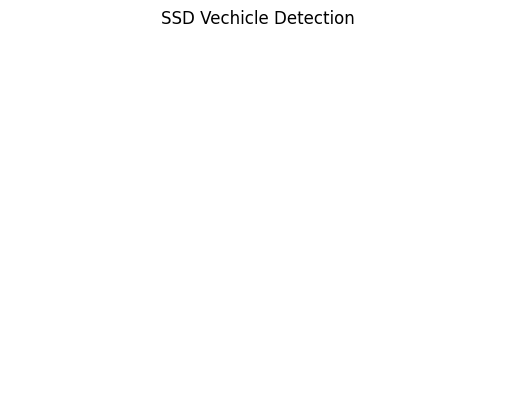

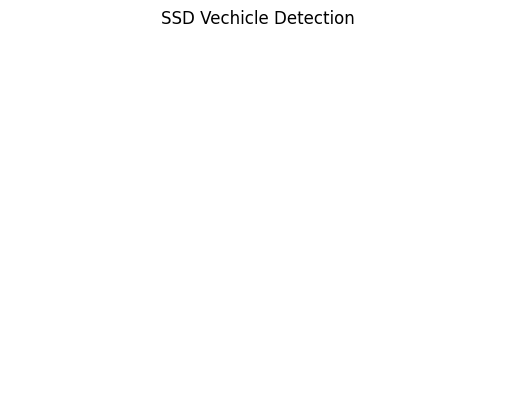

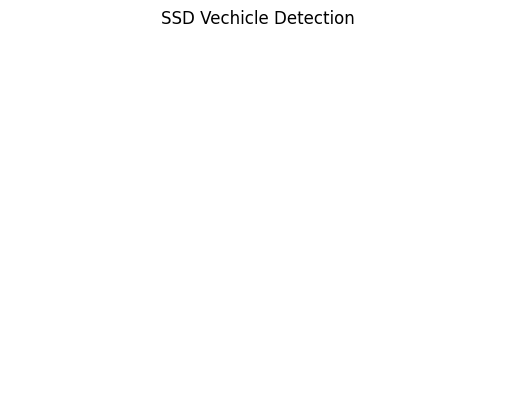

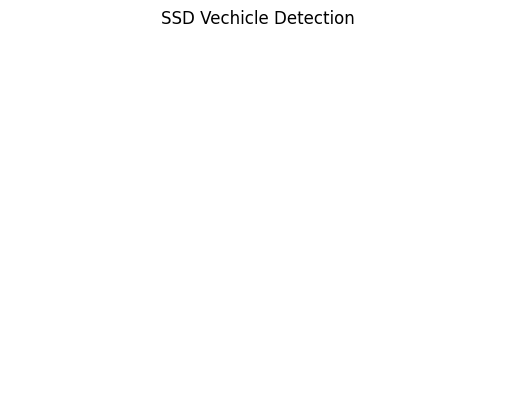

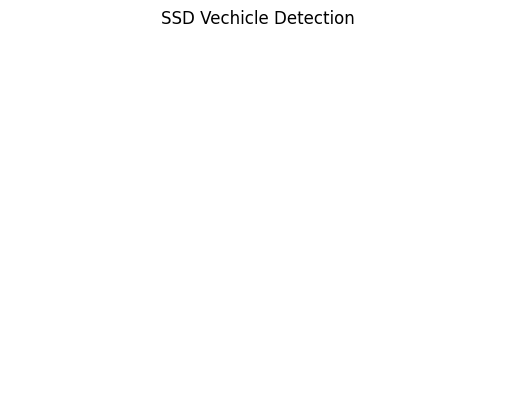

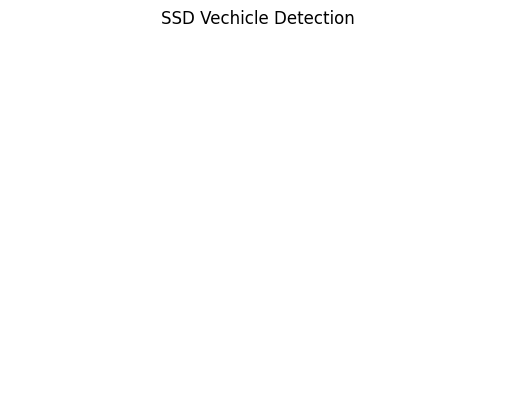

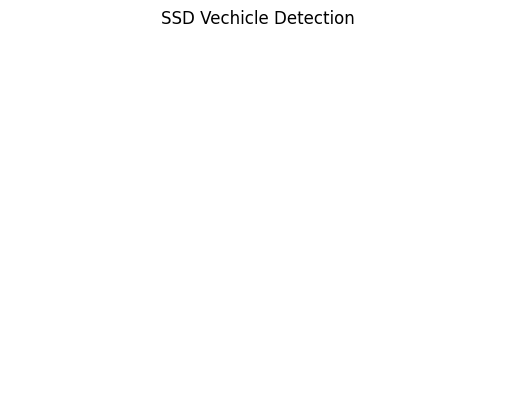

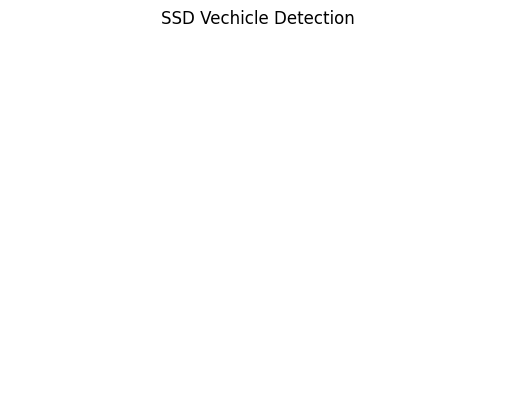

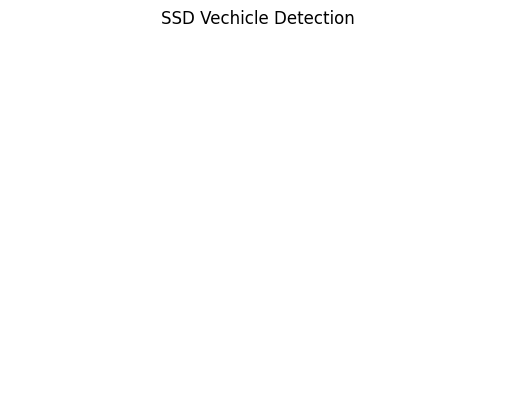

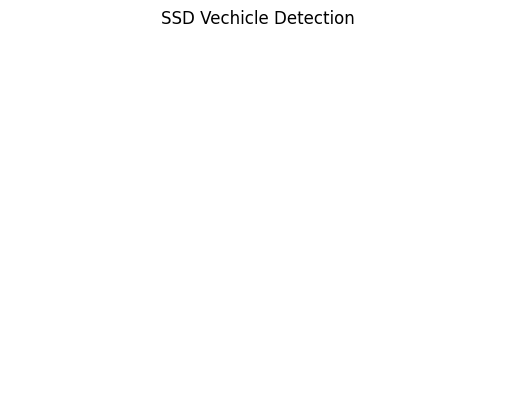

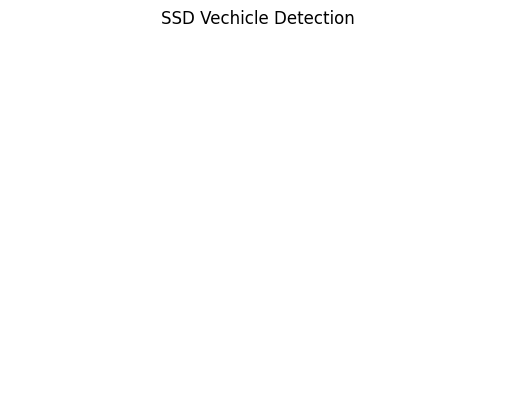

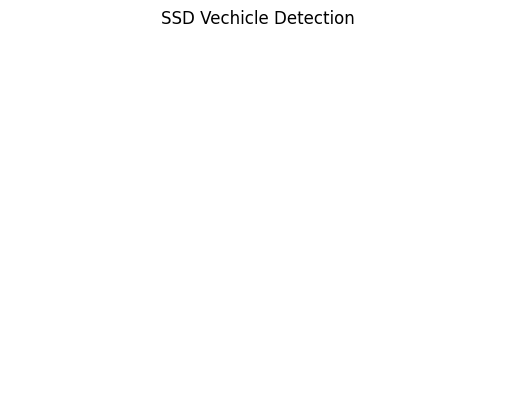

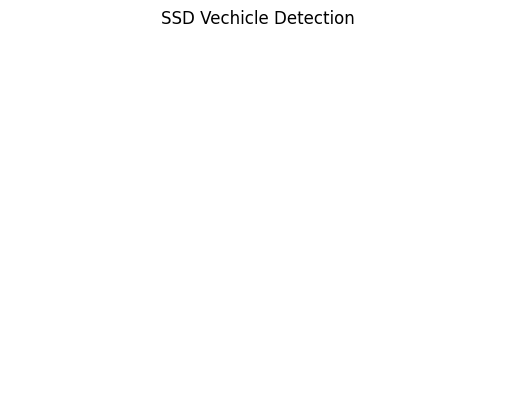

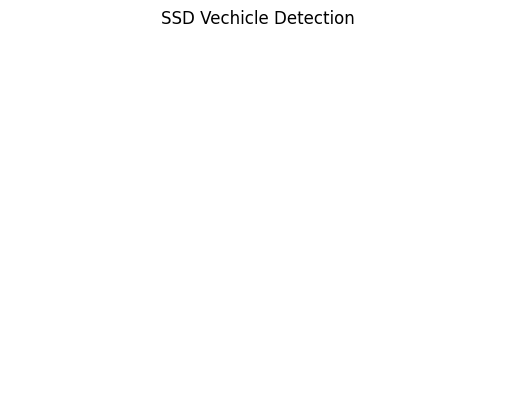

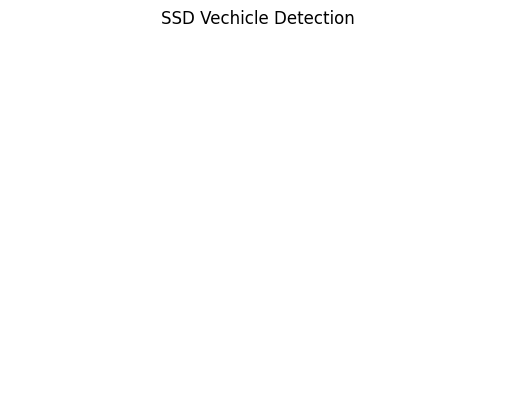

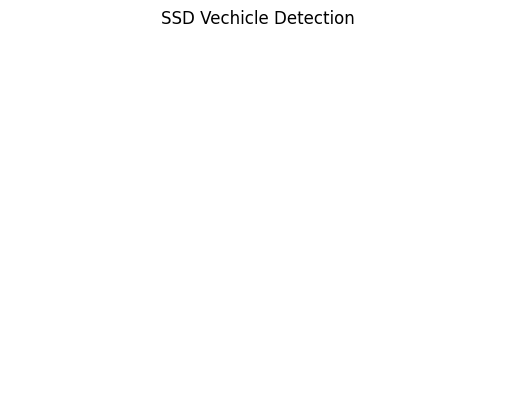

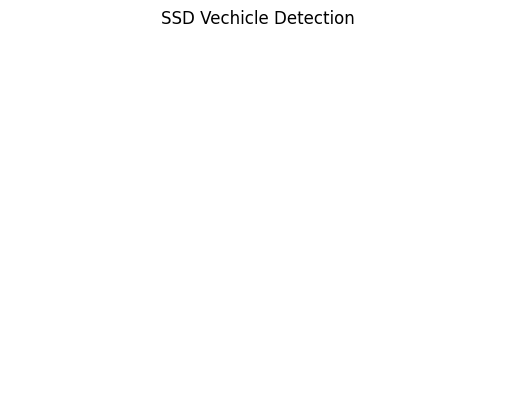

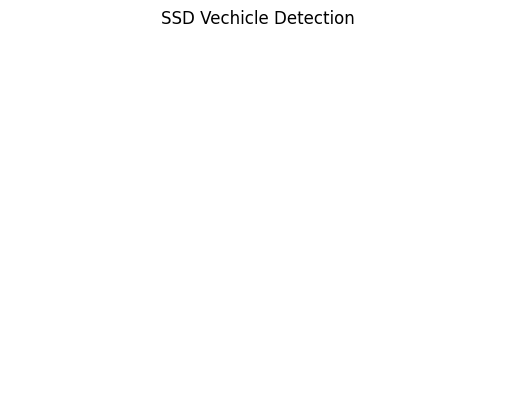

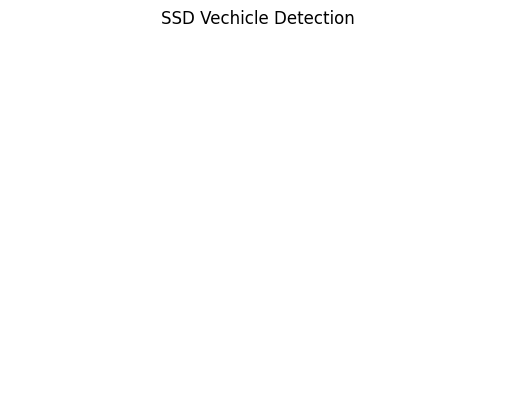

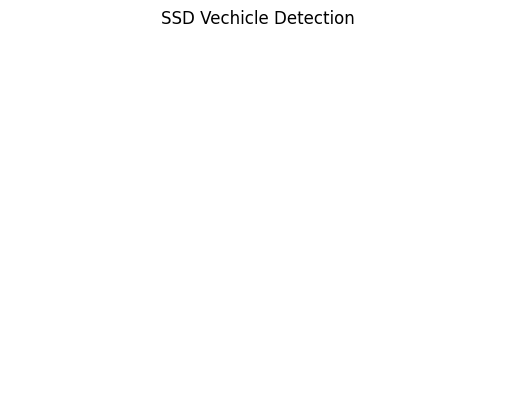

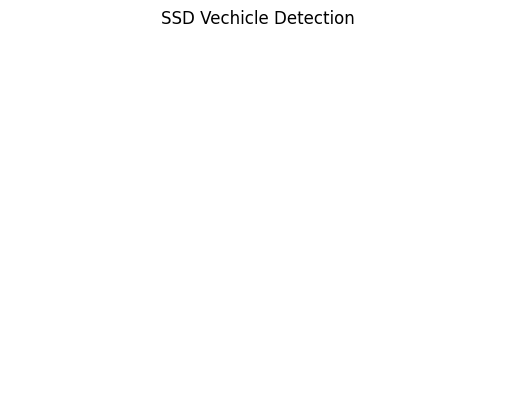

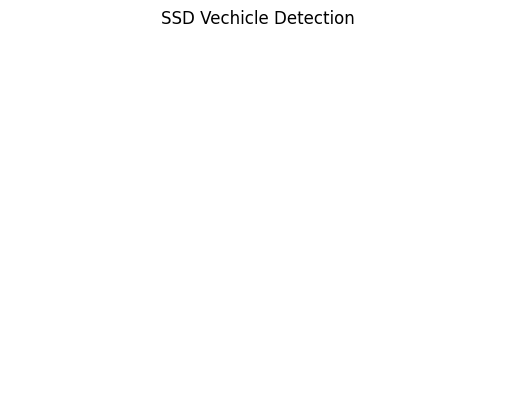

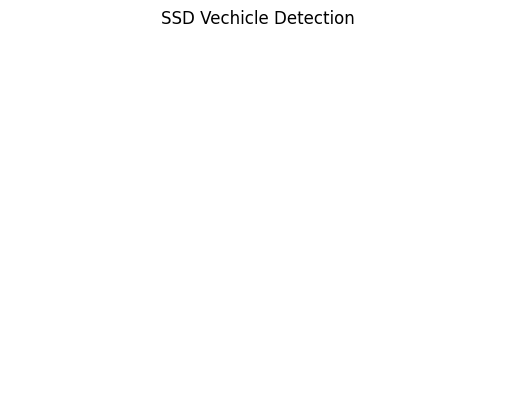

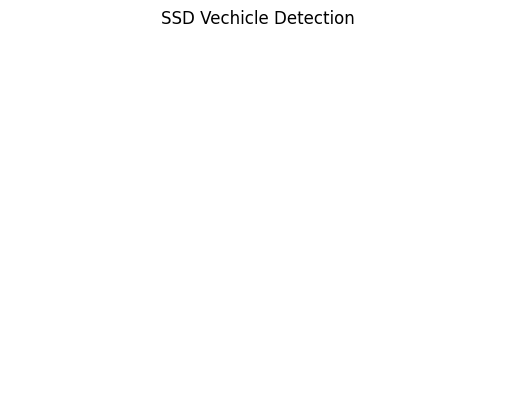

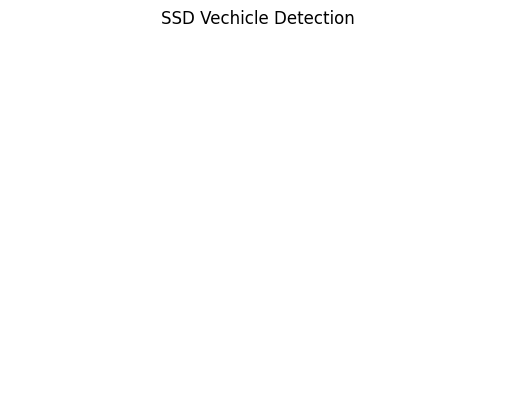

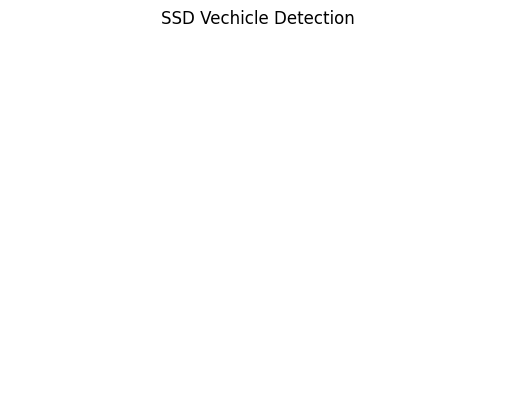

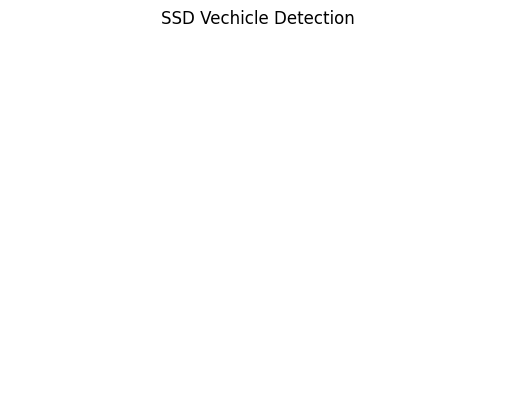

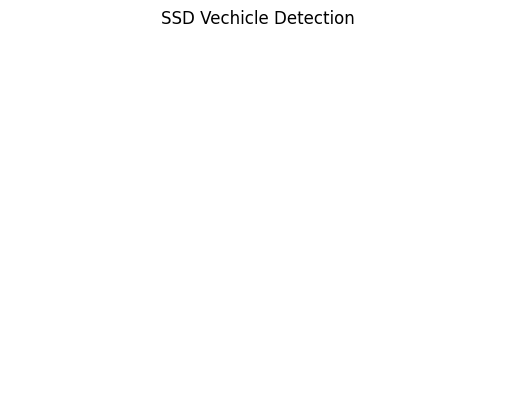

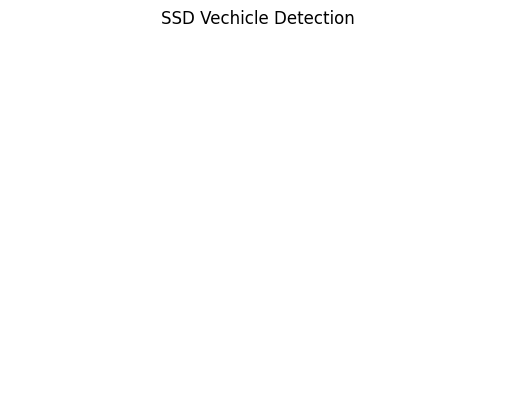

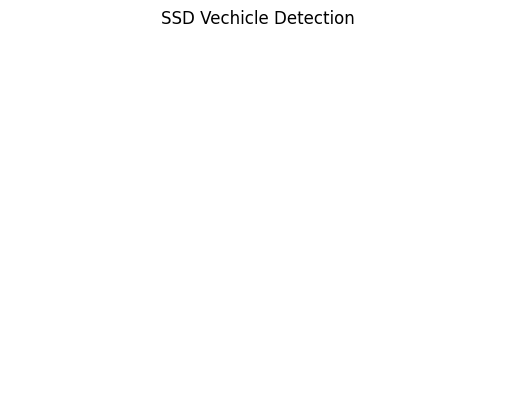

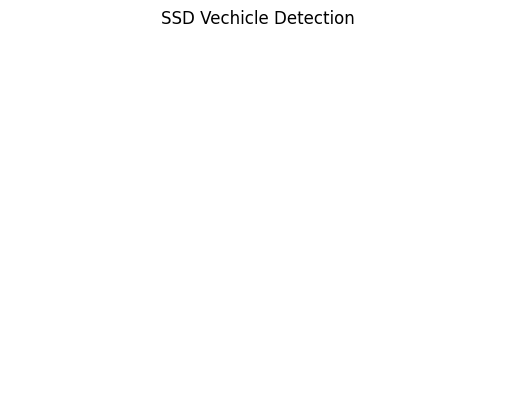

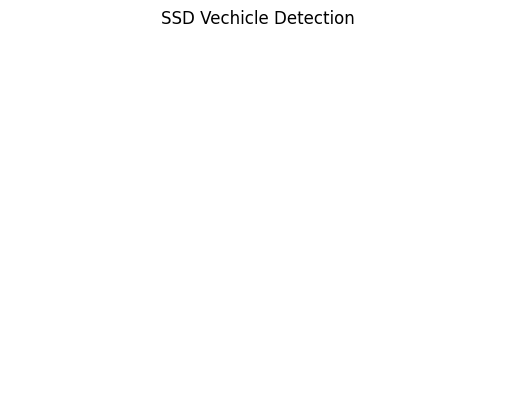

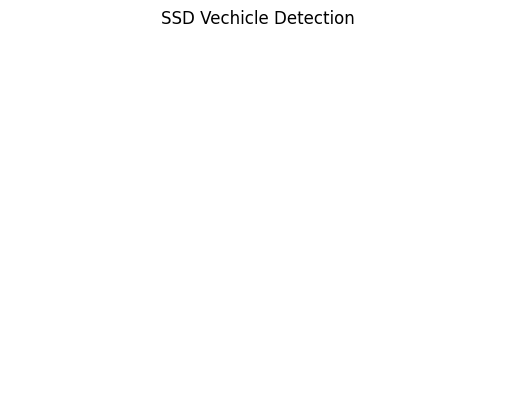

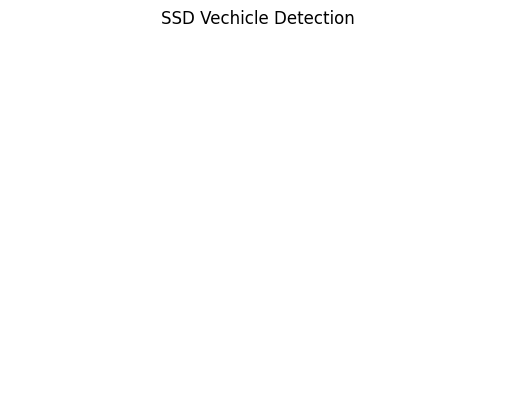

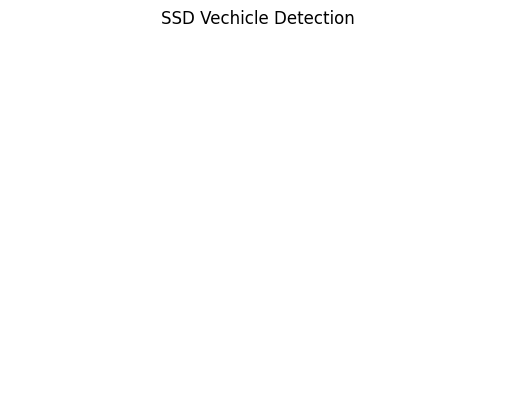

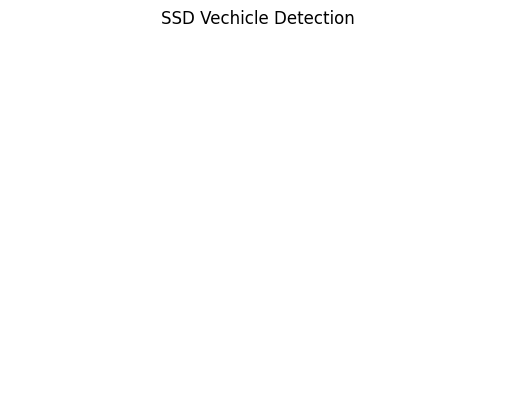

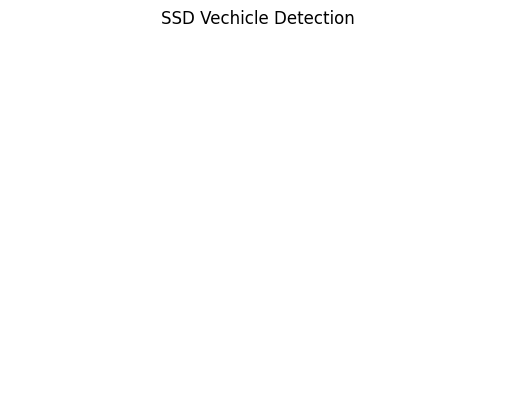

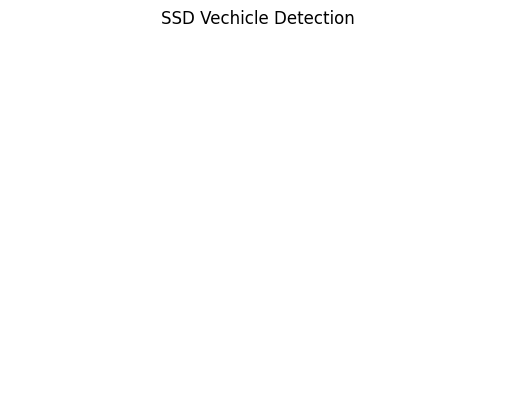

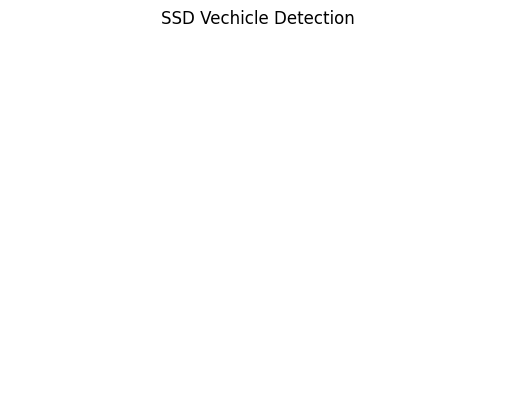

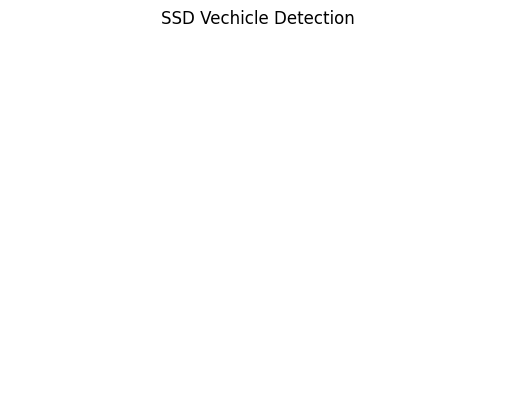

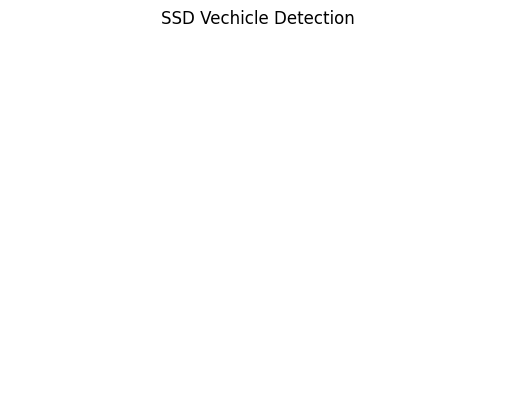

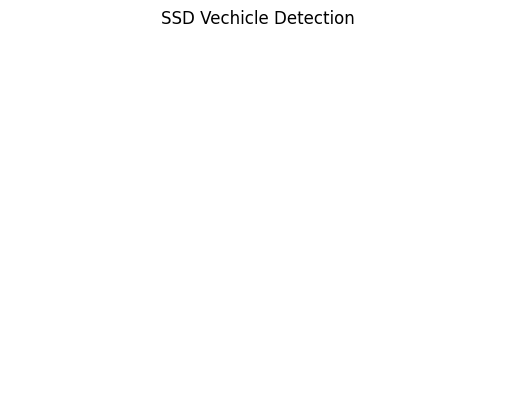

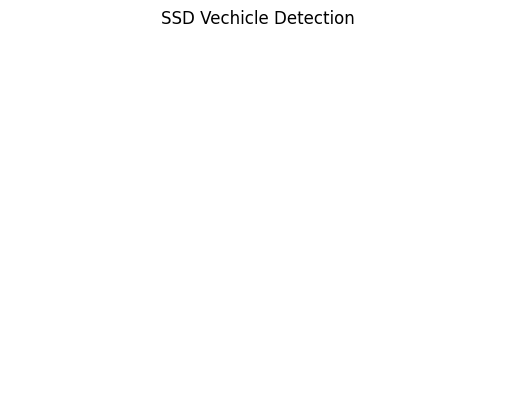

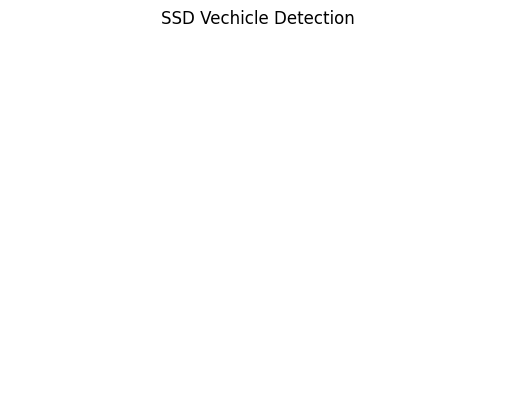

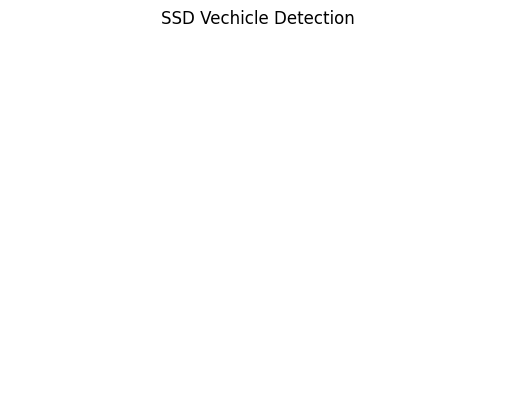

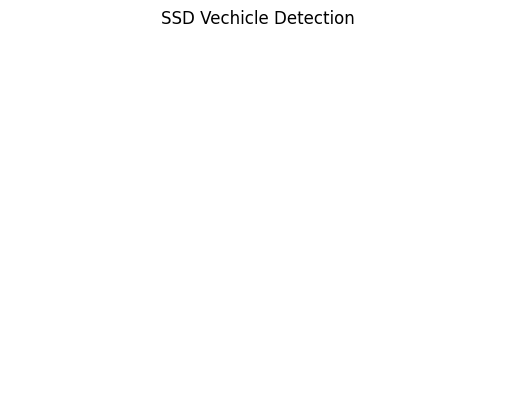

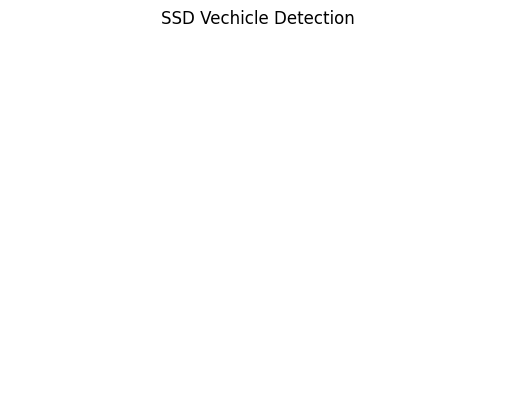

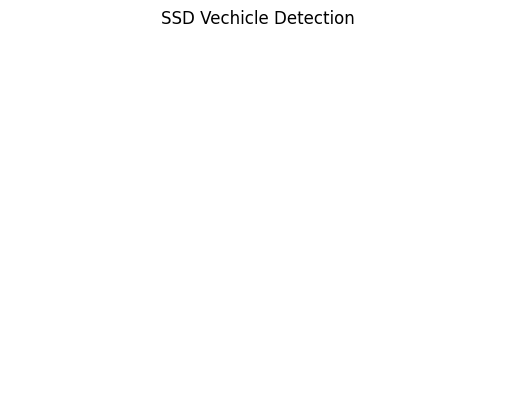

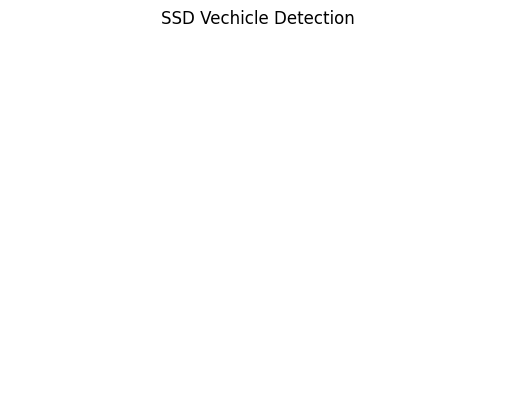

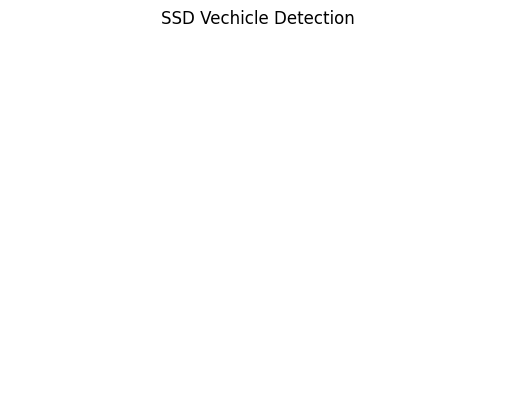

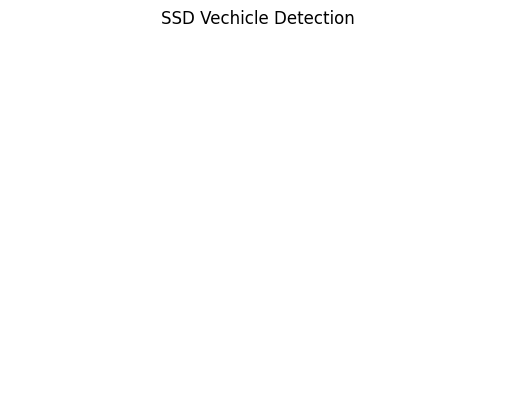

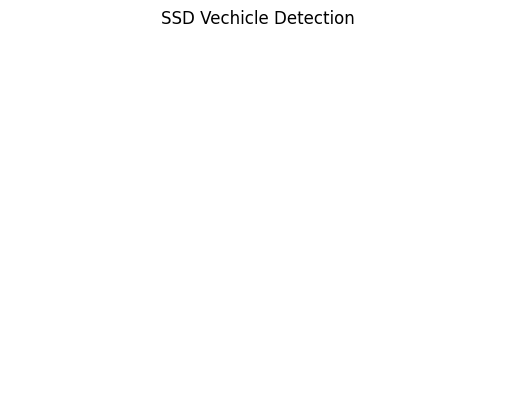

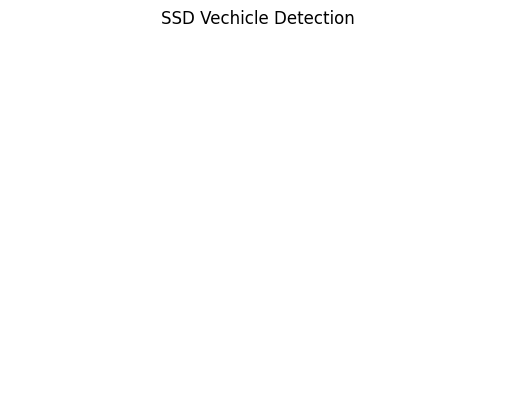

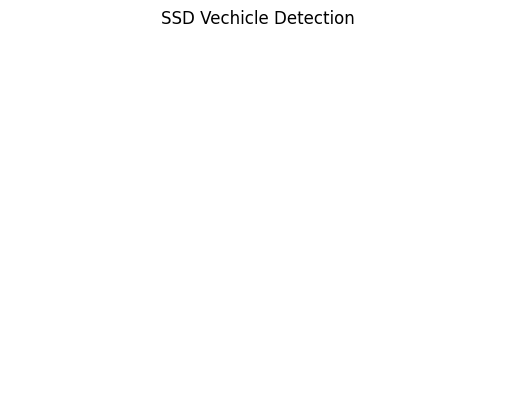

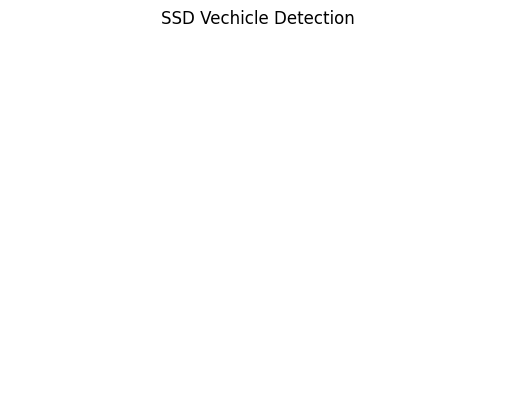

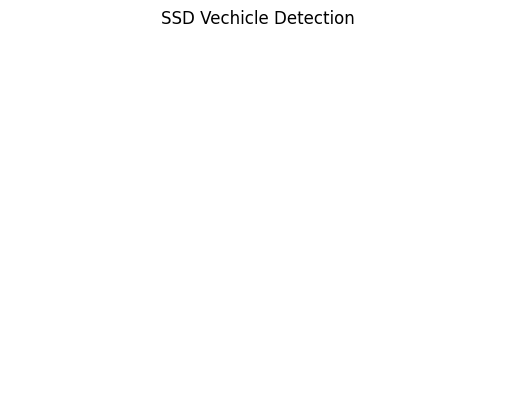

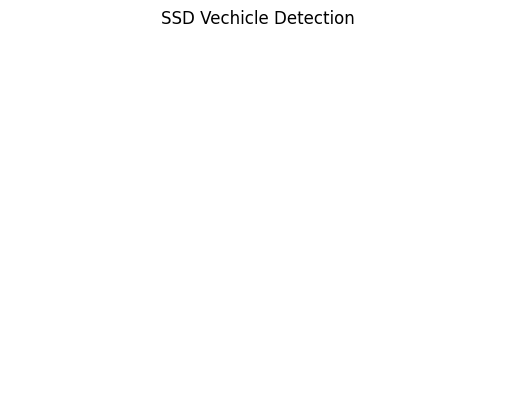

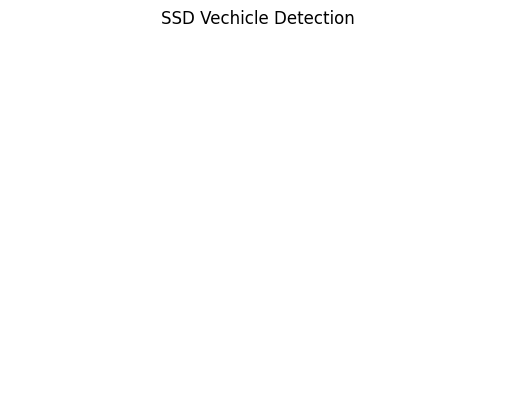

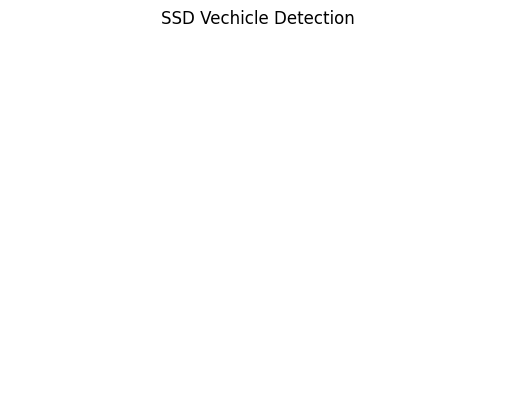

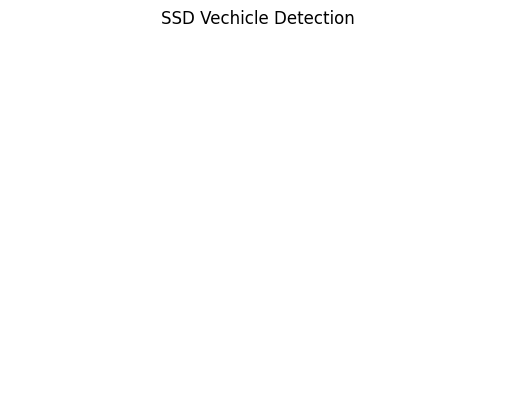

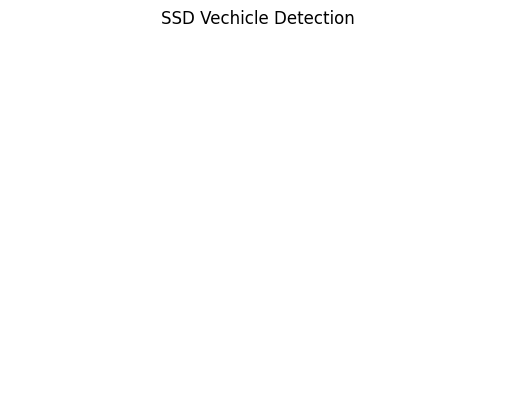

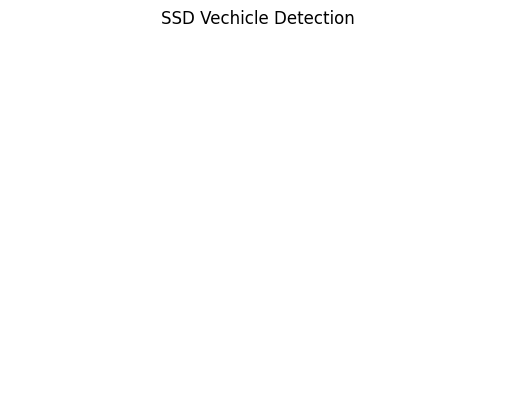

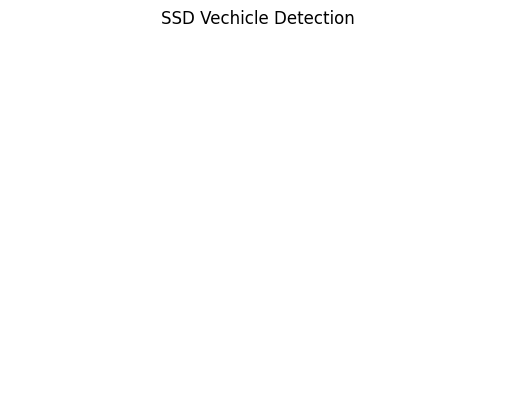

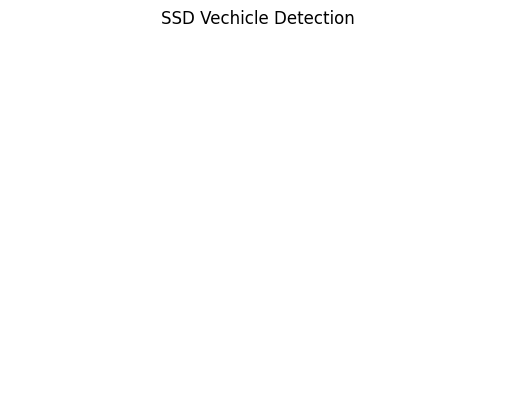

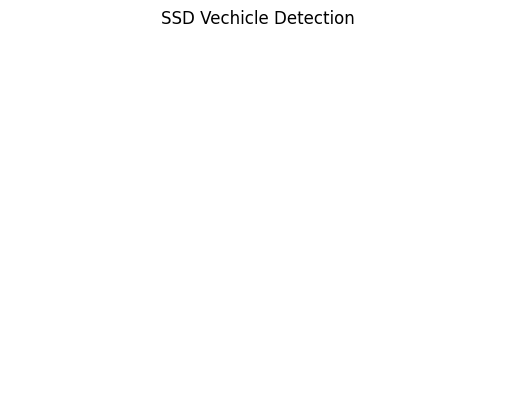

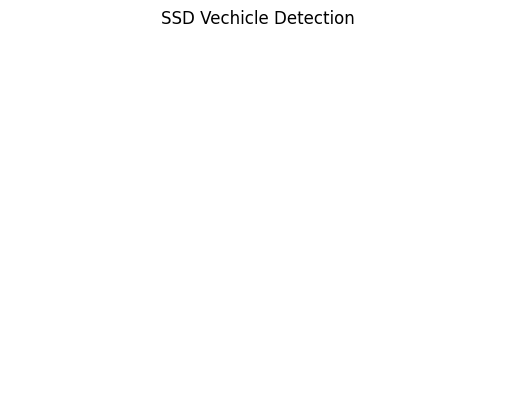

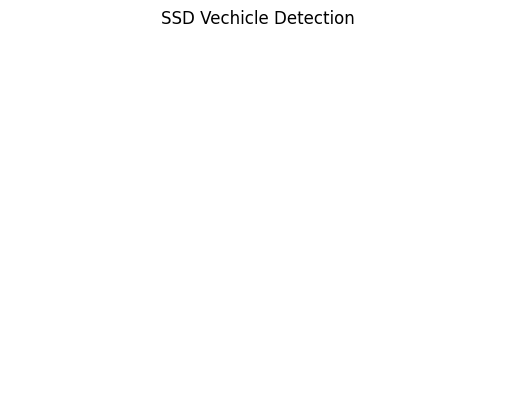

In [43]:
#DISPLAY RESULT

fig, ax = plt.subplots(figsize=(12,8))

ax.imshow(image)

vehicle_classes = ["car", "truck", "bus", "motorcycle", "bicycle"]

count = 0

for box, label, score in zip(
    prediction["boxes"],
    prediction["labels"],
    prediction["scores"]):

      if score > 0.50:

        cls = COCO_CLASSES[label]

        if cls in vehicle_classes:

          xmin, ymin, xmax, ymax = box.tolist()

          rect = patches.Rectangle(
              (xmin, ymin),
              xmax-xmin,
              ymax-ymin,
              linewidth=2,
              edgecolor="red",
              facecolor="none"
          )

          ax.add_patch(rect)

          ax.text(
              xmin,
              ymin,
              f"{cls}: {score:.2f}",
              color="yellow",
              fontsize=10,
              backgroundcolor="black"
          )

          count += 1

      plt.title("SSD Vechicle Detection")
      plt.axis("off")
      plt.show()

In [44]:
#PRINT DETECTED VEHICLES

print("\n", "="*60)

print("Detected Vehicles")

print("="*60)

for box, label, score in zip(
    prediction["boxes"],
    prediction["labels"],
    prediction["scores"]):

  if score > 0.50:
    cls = COCO_CLASSES[label]

    if cls in vehicle_classes:

      print(f"Vehicle: {cls}")
      print(f"Confidence: {score:.2f}")
      print("-"*30)

print(f"\nTotal Vehicles Detected:  {count}")



Detected Vehicles
Vehicle: car
Confidence: 0.75
------------------------------
Vehicle: car
Confidence: 0.73
------------------------------
Vehicle: car
Confidence: 0.61
------------------------------
Vehicle: car
Confidence: 0.53
------------------------------

Total Vehicles Detected:  4
